# Omi-32 evolutionary pathway analysis for competitive-capture + strong selection model

This notebook computes evolutionary trajectories for the Omi-32 antibody lineage
under different fitness models (affinity-only, antigen capture, competitive capture)
and selection strengths (strong, moderate, weak). See Methods from Tharp et al, 2026 (and code below) for details.

**Outputs used by downstream notebooks:**
- Likelihood CSVs for uphill path counting (Figure 3b)
- Edge overlap CSVs for Venn diagrams (Supplemental Figure 3b)

**Special note for strong ('uphill') path analysis**
- this notebook will output all of the analysis for the strong analysis framework, but switches to using a random sampling of 1000 of the viable paths for the 'print most likely paths' section since all uphill paths are equally likely in this model (and does the same for the 'least likely paths' section) and will compute mutation order probabilities based on uphill mutational steps
- for the strong models, we only look at comparisons between the number of uphill paths and uphill mutational steps but leave these other analyses intact for the viewer (and to maintain a consistent analysis pipeline across our models)

In [1]:
import numpy as np
from numpy.random import SeedSequence
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from collections import defaultdict
from scipy.sparse import dok_matrix, csr_matrix
from sklearn.preprocessing import normalize
import networkx as nx
import itertools
from itertools import islice
from tqdm import tqdm
from matplotlib.patches import Patch
import scipy as sp
import math
import csv
from collections import OrderedDict
import sys
import os
import matplotlib.cm as cm
import matplotlib.colors as colors

mpl.rcParams['figure.dpi'] = 100
plt.rcParams.update({'font.size': 7,'axes.linewidth':0.5,
                     'xtick.major.size':2,'xtick.major.width':0.5,
                    'ytick.major.size':2,'ytick.major.width':0.5})
plt.rcParams.update({'mathtext.default':  'regular' })

# antigen colors used throughout all plots
colorWuhan, colorBA1, colorBA4 = "#DC143C", "#228B22", "#0000CD"

# antibody being analyzed
antibody = "omi-32"

# antigens in the library
antigens = ["wuhan", "ba1", "ba4"]

# number of mutation positions in the combinatorial library
L = 13

# integer labels for all 2^L = 8192 variants
sequences_int = range(2**L)

# which fitness function to use for calculating fixation probabilities
# options: 'affinity', 'capture', 'competitive_capture'
#fitness_model = 'affinity'
#fitness_model = 'capture'
fitness_model = 'competitive_capture'

# set to True if the germline antibody does not bind (at detection limit)
# set to False if using predicted data where germline can bind
GERMLINE_NONBINDING = False

# set to True for a quick run (only single antigen + mixed scenarios)
# set to False for comprehensive analysis (all sequential scenarios)
QUICK_MODE = False

# selection strength for the evolutionary model
# 'strong': step function (delta > 0 -> fixation probability 1, else 0)
# 'moderate': Kimura formula with N=1000, gamma=1.0
# 'weak': Kimura formula with N=20, gamma=0.5
selection_strength = 'strong'
#selection_strength = 'moderate'
#selection_strength = 'weak'

# whether to normalize expression and PSR ranges to match affinity range
# required for capture/competitive_capture models to weight phenotypes equally
NORMALIZE_PHENOTYPES = True

# population size and selection coefficient for moderate/weak models
# not used for strong selection
if selection_strength == 'moderate':
    N = 1000
    gamma = 1.0
elif selection_strength == 'weak':
    N = 20
    gamma = 0.5
elif selection_strength == 'strong':
    N = None
    gamma = None

# antigen concentration for capture models (molar) - set very low to linearly approximate delta fitness to delta log10(affinity) + delta log10(expression) for antigen capture and delta log10(affinity) + delta log10(expression) - delta log10(PSR) for competitive capture
## for full explanation of this concentration choice for Tharp et al, 2026, see methods and Extended Data Figure 3e-g
### the option to change this concentration is included for users who want to explore non-linear effects of antigen concentration on fitness landscapes and evolutionary paths
ANTIGEN_CONCENTRATION = 1e-20

# polyspecificity reagent concentration for competitive capture model (molar) - set very hight to linearly approximate delta fitness to delta log10(affinity) + delta log10(expression) - delta log10(PSR) for competitive capture
## for full explanation of this concentration choice for Tharp et al, 2026, see methods and Extended Data Figure 3e-g
### the option to change this concentration is included for users who want to explore non-linear effects of PSR reagent concentration on fitness landscapes and evolutionary paths
PSR_CONCENTRATION = 1e10

# number of bootstrap replicates for uncertainty estimation
Nbootstrap = 10

# master seed for reproducible bootstrap perturbations
# each replicate nb gets an independent random stream via SeedSequence
# the same nb index produces the same perturbation across all fitness models
BOOTSTRAP_MASTER_SEED = 42
_ss = SeedSequence(BOOTSTRAP_MASTER_SEED)
_child_seeds = _ss.spawn(Nbootstrap)

# which single-antigen scenarios to analyze for path finding and plotting
# use any combination of 'wuhan', 'ba1', 'ba4'
SINGLE_ANTIGEN_SCENARIOS = ['ba1']

# whether to also analyze combination scenarios (optimal, mixed, random_median)
## not used for Tharp et al, 2026, but included for users who want to explore different antigen exposure scenarios in their own datasets
INCLUDE_COMBO_SCENARIOS = False

# build the list of scenario keys used by all downstream cells
SCENARIOS_TO_ANALYZE = [f'{ag}_only' for ag in SINGLE_ANTIGEN_SCENARIOS]
if INCLUDE_COMBO_SCENARIOS:
    SCENARIOS_TO_ANALYZE += ['optimal', 'average_mixed', 'random_median']

# number of uphill paths to sample for strong selection
# or top-k most/least likely paths for moderate/weak selection
NUM_BEST_PATHS = 1000
NUM_WORST_PATHS = 1000

# output directory configuration
# maps fitness_model to the top-level folder name
_model_dir_map = {
    'affinity': 'affinity_only',
    'capture': 'antigen_capture',
    'competitive_capture': 'competitive_antigen_capture',
}

# maps fitness_model to the plot title label
_model_title_map = {
    'affinity': 'affinity-only',
    'capture': 'antigen capture',
    'competitive_capture': 'competitive capture',
}

MODEL_DIR_PREFIX = _model_dir_map[fitness_model]
TITLE_LABEL = _model_title_map[fitness_model]

# build subdirectory name based on model, selection strength, and normalization
if fitness_model == 'affinity':
    _subdir_suffix = f'{selection_strength}_data'
    _img_suffix = f'{selection_strength}_images'
elif fitness_model == 'capture':
    import math as _math
    _exp = int(_math.log10(ANTIGEN_CONCENTRATION))
    _coeff = ANTIGEN_CONCENTRATION / (10**_exp)
    _conc_str = f'{_coeff:g}e{_exp}'
    if NORMALIZE_PHENOTYPES:
        _subdir_suffix = f'{selection_strength}_norm_data'
        _img_suffix = f'{selection_strength}_norm_images'
    else:
        _subdir_suffix = f'{selection_strength}_data'
        _img_suffix = f'{selection_strength}_images'
elif fitness_model == 'competitive_capture':
    if NORMALIZE_PHENOTYPES:
        _subdir_suffix = f'{selection_strength}_norm_data'
        _img_suffix = f'{selection_strength}_norm_images'
    else:
        _subdir_suffix = f'{selection_strength}__data'
        _img_suffix = f'{selection_strength}__images'

DATA_DIR = f'{MODEL_DIR_PREFIX}/{_subdir_suffix}'
IMAGE_DIR = f'{MODEL_DIR_PREFIX}/{_img_suffix}'

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(IMAGE_DIR, exist_ok=True)

print(f"Output directories:")
print(f"  DATA_DIR  = {DATA_DIR}")
print(f"  IMAGE_DIR = {IMAGE_DIR}")
print(f"  Title     = {TITLE_LABEL}")
print(f"  Scenarios = {SCENARIOS_TO_ANALYZE}")


def mutation(s, ii, L):
    """Return sequence s with a somatic mutation added at position ii."""
    return s | 2**(L-1-ii)

def nb_mutation(s):
    """Count the number of mutations in variant s."""
    return bin(s).count("1")

def reachable(s, L):
    """Return list of sequences reachable by adding one mutation to s."""
    return [(s | 2**ii) for ii in range(L) if (s | 2**ii) > s]

def k_shortest_paths(G, source, target, k, weight=None):
    """Return the k shortest simple paths from source to target."""
    return list(
        islice(nx.shortest_simple_paths(G, source, target, weight=weight), k)
    )

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    """Return a truncated version of a colormap."""
    new_cmap = colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap


Output directories:
  DATA_DIR  = competitive_antigen_capture/strong_norm_data
  IMAGE_DIR = competitive_antigen_capture/strong_norm_images
  Title     = competitive capture
  Scenarios = ['ba1_only']


## Load and prepare data

In [2]:
# load epistatic model predictions for each phenotype
wuhan = pd.read_csv('../epistasis_inference/linear_interaction_models/wuhan/reference-based/predicted_phenotypes/wuhan_raw_2order_full_biochem_predictions.csv')
wuhan['geno'] = wuhan['geno'].astype('string').str.zfill(13)
wuhan['wuhan_log10kd_mean'] = wuhan['predicted_phenotype']
wuhan['wuhan_log10kd_sem'] = wuhan['prediction_se']
wuhan = wuhan[['geno','wuhan_log10kd_mean','wuhan_log10kd_sem']]

ba1 = pd.read_csv('../epistasis_inference/linear_interaction_models/ba1/reference-based/predicted_phenotypes/ba1_raw_3order_full_biochem_predictions.csv')
ba1['geno'] = ba1['geno'].astype('string').str.zfill(13)
ba1['ba1_log10kd_mean'] = ba1['predicted_phenotype']
ba1['ba1_log10kd_sem'] = ba1['prediction_se']
ba1 = ba1[['geno','ba1_log10kd_mean','ba1_log10kd_sem']]

ba4 = pd.read_csv('../epistasis_inference/linear_interaction_models/ba4/reference-based/predicted_phenotypes/ba4_raw_3order_full_biochem_predictions.csv')
ba4['ba4_log10kd_mean'] = ba4['predicted_phenotype']
ba4['ba4_log10kd_sem'] = ba4['prediction_se']
ba4 = ba4[['geno','ba4_log10kd_mean','ba4_log10kd_sem']]
ba4['geno'] = ba4['geno'].astype('string').str.zfill(13)

expression = pd.read_csv('../epistasis_inference/linear_interaction_models/expression/reference-based/predicted_phenotypes/expression_raw_2order_full_biochem_predictions.csv')
expression['geno'] = expression['geno'].astype('string').str.zfill(13)
expression['mednorm_mean'] = expression['predicted_phenotype']
expression['mednorm_sem'] = expression['prediction_se']
expression = expression[['geno','mednorm_mean','mednorm_sem']]

psr = pd.read_csv('../epistasis_inference/linear_interaction_models/psr/reference-based/predicted_phenotypes/psr_raw_2order_full_biochem_predictions.csv')
psr['geno'] = psr['geno'].astype('string').str.zfill(13)
psr['ec50_mean'] = psr['predicted_phenotype']
psr['ec50_sem'] = psr['prediction_se']
psr = psr[['geno','ec50_mean','ec50_sem']]

# merge all phenotypes into a single dataframe
df_merge = wuhan.merge(ba1, on='geno', how='outer')
df_merge = df_merge.merge(ba4, on='geno', how='outer')
df_merge = df_merge.merge(expression, on='geno', how='outer')
df_merge = df_merge.merge(psr, on='geno', how='outer')
df_merge['variant'] = df_merge['geno']


In [3]:
# assign merged data and zero-fill variant strings
df = df_merge
df['variant'] = df['variant'].apply(lambda x: str(x).zfill(L))

# rename columns to standardized format
df = df.rename(columns={
    "wuhan_log10kd_mean": "wuhan_log10Kd",
    "ba1_log10kd_mean": "ba1_log10Kd",
    "ba4_log10kd_mean": "ba4_log10Kd",
    "wuhan_log10kd_sem": "wuhan_stelog10Kd",
    "ba1_log10kd_sem": "ba1_stelog10Kd",
    "ba4_log10kd_sem": "ba4_stelog10Kd",
    "mednorm_mean": "expression_log10",
    "mednorm_sem": "expression_stelog10",
    "ec50_mean": "psr_neglog10ec50",
    "ec50_sem": "psr_stelog10ec50"
})

# convert genotypes to integers and sort
df["variant_int"] = df.variant.apply(lambda x: int(x, 2))
df = df.set_index("variant_int").reindex(range(0, 2**L)).reset_index()

# reconstruct variant string for any missing rows
df['variant'] = df['variant'].fillna(df['variant_int'].apply(lambda x: format(x, f'0{L}b')))

# create boolean columns for each mutation position
for ii in range(L):
    df[f"mutation_{ii+1}"] = df.variant.str[ii] == '1'

# calculate average Kd for mixed scenarios
df['mixed_log10Kd'] = df[[f"{a}_log10Kd" for a in antigens]].mean(axis=1)

# data validation
print("=" * 60)
print("DATA VALIDATION REPORT")
print("=" * 60)

print(f"\nTotal variants in dataframe: {len(df)} (expected: {2**L})")
assert len(df) == 2**L, f"ERROR: Expected {2**L} variants, got {len(df)}"

required_columns = (
    [f"{a}_log10Kd" for a in antigens] +
    [f"{a}_stelog10Kd" for a in antigens] +
    ['expression_log10', 'expression_stelog10',
     'psr_neglog10ec50', 'psr_stelog10ec50',
     'variant', 'variant_int', 'mixed_log10Kd']
)

missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    print(f"\nERROR: Missing required columns: {missing_columns}")
    raise ValueError(f"Missing columns: {missing_columns}")
else:
    print(f"\n✓ All required columns present")

print(f"\nMISSING DATA SUMMARY:")
print(f"  Variants with missing wuhan affinity: {df['wuhan_log10Kd'].isna().sum()}")
print(f"  Variants with missing ba1 affinity: {df['ba1_log10Kd'].isna().sum()}")
print(f"  Variants with missing ba4 affinity: {df['ba4_log10Kd'].isna().sum()}")
print(f"  Variants with missing expression: {df['expression_log10'].isna().sum()}")
print(f"  Variants with missing PSR: {df['psr_neglog10ec50'].isna().sum()}")
print(f"  Variants with missing mixed_log10Kd: {df['mixed_log10Kd'].isna().sum()}")

print(f"\nDATA RANGE CHECKS:")
for antigen in antigens:
    kd_col = f"{antigen}_log10Kd"
    if df[kd_col].notna().any():
        print(f"  {antigen} affinity (-log10Kd): [{df[kd_col].min():.2f}, {df[kd_col].max():.2f}]")

if df['expression_log10'].notna().any():
    print(f"  Expression (log10): [{df['expression_log10'].min():.2f}, {df['expression_log10'].max():.2f}]")

if df['psr_neglog10ec50'].notna().any():
    print(f"  PSR (-log10EC50): [{df['psr_neglog10ec50'].min():.2f}, {df['psr_neglog10ec50'].max():.2f}]")

germline_int = 0
somatic_int = 2**L - 1

print(f"\nKEY SEQUENCES:")
print(f"  Germline (all 0s, int={germline_int}):")
germline_row = df.loc[df['variant_int'] == germline_int].iloc[0]
print(f"    wuhan: {germline_row['wuhan_log10Kd']:.3f}")
print(f"    expression: {germline_row['expression_log10']:.3f}")
print(f"    PSR: {germline_row['psr_neglog10ec50']:.3f}")

print(f"\n  Somatic (all 1s, int={somatic_int}):")
somatic_row = df.loc[df['variant_int'] == somatic_int].iloc[0]
print(f"    wuhan: {somatic_row['wuhan_log10Kd']:.3f}")
print(f"    expression: {somatic_row['expression_log10']:.3f}")
print(f"    PSR: {somatic_row['psr_neglog10ec50']:.3f}")

print(f"\nFIRST 5 ROWS:")
display_cols = ['variant', 'variant_int', 'wuhan_log10Kd', 'ba1_log10Kd',
                'ba4_log10Kd', 'expression_log10', 'psr_neglog10ec50']
print(df[display_cols].head())

print("=" * 60)
print("✓ DATA VALIDATION COMPLETE")
print("=" * 60)


DATA VALIDATION REPORT

Total variants in dataframe: 8192 (expected: 8192)

✓ All required columns present

MISSING DATA SUMMARY:
  Variants with missing wuhan affinity: 0
  Variants with missing ba1 affinity: 0
  Variants with missing ba4 affinity: 0
  Variants with missing expression: 0
  Variants with missing PSR: 0
  Variants with missing mixed_log10Kd: 0

DATA RANGE CHECKS:
  wuhan affinity (-log10Kd): [5.85, 9.93]
  ba1 affinity (-log10Kd): [6.51, 9.95]
  ba4 affinity (-log10Kd): [6.63, 9.42]
  Expression (log10): [3.82, 4.42]
  PSR (-log10EC50): [0.93, 2.23]

KEY SEQUENCES:
  Germline (all 0s, int=0):
    wuhan: 6.709
    expression: 4.228
    PSR: 2.122

  Somatic (all 1s, int=8191):
    wuhan: 9.494
    expression: 4.324
    PSR: 1.610

FIRST 5 ROWS:
         variant  variant_int  wuhan_log10Kd  ba1_log10Kd  ba4_log10Kd  \
0  0000000000000            0       6.709208     7.398105     6.874339   
1  0000000000001            1       6.734938     7.484630     6.835322   
2  00000

In [4]:
# calculate phenotype ranges for normalization
print("Calculating phenotype ranges...")

affinity_ranges = {}
for ag in antigens:
    col = f"{ag}_log10Kd"
    affinity_ranges[ag] = df[col].max() - df[col].min()
    print(f"  {ag} affinity range: {affinity_ranges[ag]:.3f} log10 units")

# use the average affinity range as the normalization target
## we originally wanted to use this notebook to explore differences in antigen exposure scenarios and determined averaging the affinity range across antigens was the most principled way to set a common normalization target for all phenotypes without biasing towards any single antigen
### that said, this approach applies robustly to just looking at BA.1, given that the ranges is only 0.02 log10 units off of the BA.1 affinity range alone
TARGET_RANGE = np.mean(list(affinity_ranges.values()))
print(f"  Target range (mean affinity): {TARGET_RANGE:.3f} log10 units")

EXPR_MIN = df['expression_log10'].min()
EXPR_MAX = df['expression_log10'].max()
EXPR_RANGE = EXPR_MAX - EXPR_MIN
print(f"  Expression range: {EXPR_RANGE:.3f} log10 units")

PSR_MIN = df['psr_neglog10ec50'].min()
PSR_MAX = df['psr_neglog10ec50'].max()
PSR_RANGE = PSR_MAX - PSR_MIN
print(f"  PSR range: {PSR_RANGE:.3f} log10 units")

# compute scale factors so expression and PSR span the same range as affinity
if NORMALIZE_PHENOTYPES:
    EXPR_SCALE = TARGET_RANGE / EXPR_RANGE
    PSR_SCALE = TARGET_RANGE / PSR_RANGE
    print(f"\nNormalization ENABLED:")
    print(f"  Expression scale factor: {EXPR_SCALE:.2f}x")
    print(f"  PSR scale factor: {PSR_SCALE:.2f}x")
    print(f"\n  After scaling:")
    print(f"    Expression effective range: {EXPR_RANGE * EXPR_SCALE:.3f} log10 units")
    print(f"    PSR effective range: {PSR_RANGE * PSR_SCALE:.3f} log10 units")
else:
    EXPR_SCALE = 1.0
    PSR_SCALE = 1.0
    print(f"\nNormalization DISABLED (scale factors = 1.0)")


Calculating phenotype ranges...
  wuhan affinity range: 4.077 log10 units
  ba1 affinity range: 3.438 log10 units
  ba4 affinity range: 2.792 log10 units
  Target range (mean affinity): 3.436 log10 units
  Expression range: 0.605 log10 units
  PSR range: 1.300 log10 units

Normalization ENABLED:
  Expression scale factor: 5.68x
  PSR scale factor: 2.64x

  After scaling:
    Expression effective range: 3.436 log10 units
    PSR effective range: 3.436 log10 units


In [5]:
def fixation_probability_moderate(fitness_s, fitness_t, Npop, gamma):
    """
    Fixation probability under moderate/weak selection.
    Uses Kimura's formula: p = (1 - exp(-gamma*delta)) / (1 - exp(-N*gamma*delta))
    """
    if np.isnan(fitness_s) or np.isnan(fitness_t):
        pval = 0.0
    else:
        delta = fitness_t - fitness_s
        if delta == 0.0:
            pval = 1.0 / Npop
        else:
            pval = ((1 - np.exp(-gamma * delta)) / (1 - np.exp(-Npop * gamma * delta)))
    return pval


def fixation_probability_binary(s, fitness_s, fitness_t):
    """
    Fixation probability under strong selection.
    Step function: probability = 1 if fitness improves, 0 otherwise.
    If GERMLINE_NONBINDING is True, all first mutations from germline are allowed.
    """
    if nb_mutation(s) == 0 and GERMLINE_NONBINDING:
        pval = 1.0
    elif np.isnan(fitness_s) or np.isnan(fitness_t):
        pval = 0.0
    elif (fitness_t - fitness_s) > 0:
        pval = 1.0
    else:
        pval = 0.0
    return pval


def get_fixation_probability(s, fitness_s, fitness_t):
    """Wrapper that calls the correct fixation function based on selection_strength."""
    if selection_strength == 'strong':
        return fixation_probability_binary(s, fitness_s, fitness_t)
    else:
        return fixation_probability_moderate(fitness_s, fitness_t, N, gamma)


In [6]:
def calculate_fitness(ag, bootstrap_replicate=None):
    """
    Calculate fitness for all genotypes under a given antigen context.
    If bootstrap_replicate is None, uses mean values.
    If bootstrap_replicate is an int, samples from normal(mean, SEM).
    """

    if bootstrap_replicate is not None:
        # sample from normal distribution using mean and SEM
        if ag != "mixed":
            affinity = np.random.normal(
                df[f"{ag}_log10Kd"].values.astype('float32'),
                df[f"{ag}_stelog10Kd"].values.astype('float32')
            )
        else:
            affinity = sum([
                np.random.normal(
                    df[f"{aa}_log10Kd"].values.astype('float32'),
                    df[f"{aa}_stelog10Kd"].values.astype('float32')
                ) for aa in antigens
            ]) / len(antigens)

        expression = np.random.normal(
            df['expression_log10'].values.astype('float32'),
            df['expression_stelog10'].values.astype('float32')
        )
        psr = np.random.normal(
            df['psr_neglog10ec50'].values.astype('float32'),
            df['psr_stelog10ec50'].values.astype('float32')
        )
    else:
        # use mean values (no bootstrap)
        if ag != "mixed":
            affinity = df[f"{ag}_log10Kd"].values.astype('float32')
        else:
            affinity = df['mixed_log10Kd'].values.astype('float32')

        expression = df['expression_log10'].values.astype('float32')
        psr = df['psr_neglog10ec50'].values.astype('float32')

    # apply normalization if enabled
    if NORMALIZE_PHENOTYPES:
        expression_scaled = EXPR_MIN + (expression - EXPR_MIN) * EXPR_SCALE
        psr_scaled = PSR_MIN + (psr - PSR_MIN) * PSR_SCALE
    else:
        expression_scaled = expression
        psr_scaled = psr

    # compute fitness based on model
    if fitness_model == 'affinity':
        fitness = affinity

    elif fitness_model == 'capture':
        expression_linear = 10**expression_scaled
        kd_linear = 10**(-affinity)
        fraction_bound = ANTIGEN_CONCENTRATION / (ANTIGEN_CONCENTRATION + kd_linear)
        capture_linear = expression_linear * fraction_bound
        fitness = np.log10(capture_linear)

    elif fitness_model == 'competitive_capture':
        expression_linear = 10**expression_scaled
        kd_linear = 10**(-affinity)
        ec50_linear = 10**(-psr_scaled)
        penalty_term = 1 + PSR_CONCENTRATION / ec50_linear
        denominator = ANTIGEN_CONCENTRATION + kd_linear * penalty_term
        fraction_bound = ANTIGEN_CONCENTRATION / denominator
        capture_linear = expression_linear * fraction_bound
        fitness = np.log10(capture_linear)

    else:
        raise ValueError(f"Unknown fitness_model: {fitness_model}")

    return fitness


# diagnostic: compare fitness with and without normalization
print("\n" + "=" * 60)
print("DIAGNOSTIC: Fitness comparison (germline vs somatic)")
print("=" * 60)

_original_normalize = NORMALIZE_PHENOTYPES

NORMALIZE_PHENOTYPES = False
EXPR_SCALE = 1.0
PSR_SCALE = 1.0

fitness_off = {}
for model in ['affinity', 'capture', 'competitive_capture']:
    _original_model = fitness_model
    fitness_model = model
    f = calculate_fitness('ba1', bootstrap_replicate=None)
    fitness_off[model] = {
        'germline': f[0],
        'somatic': f[2**L - 1],
        'delta': f[2**L - 1] - f[0]
    }
    fitness_model = _original_model

print("\nWithout normalization:")
for model, vals in fitness_off.items():
    print(f"  {model:25s}: germline={vals['germline']:.2f}, somatic={vals['somatic']:.2f}, delta={vals['delta']:.2f}")

NORMALIZE_PHENOTYPES = True
EXPR_SCALE = TARGET_RANGE / EXPR_RANGE
PSR_SCALE = TARGET_RANGE / PSR_RANGE

fitness_on = {}
for model in ['affinity', 'capture', 'competitive_capture']:
    _original_model = fitness_model
    fitness_model = model
    f = calculate_fitness('ba1', bootstrap_replicate=None)
    fitness_on[model] = {
        'germline': f[0],
        'somatic': f[2**L - 1],
        'delta': f[2**L - 1] - f[0]
    }
    fitness_model = _original_model

print("\nWith normalization:")
for model, vals in fitness_on.items():
    print(f"  {model:25s}: germline={vals['germline']:.2f}, somatic={vals['somatic']:.2f}, delta={vals['delta']:.2f}")

NORMALIZE_PHENOTYPES = _original_normalize
if NORMALIZE_PHENOTYPES:
    EXPR_SCALE = TARGET_RANGE / EXPR_RANGE
    PSR_SCALE = TARGET_RANGE / PSR_RANGE
else:
    EXPR_SCALE = 1.0
    PSR_SCALE = 1.0

print("\n" + "=" * 60)
print(f"Current setting: NORMALIZE_PHENOTYPES = {NORMALIZE_PHENOTYPES}")
print("=" * 60)


# build transition matrices for each bootstrap replicate
print("Building transition matrices...")
pmut = {}

for nb in tqdm(range(Nbootstrap)):
    # set reproducible per-replicate seed
    np.random.seed(_child_seeds[nb].generate_state(1)[0])

    for ag in antigens + ["mixed"]:
        pmut[ag, nb] = dok_matrix((2**L, 2**L), dtype=np.float64)
        fitnesses = calculate_fitness(ag, bootstrap_replicate=nb)

        for s in sequences_int:
            for t in reachable(s, L):
                pmut[ag, nb][s, t] = get_fixation_probability(s, fitnesses[s], fitnesses[t])

        pmut[ag, nb] = pmut[ag, nb].tocsr()

print("✓ Transition matrices complete")



DIAGNOSTIC: Fitness comparison (germline vs somatic)

Without normalization:
  affinity                 : germline=7.40, somatic=9.85, delta=2.45
  capture                  : germline=-8.37, somatic=-5.83, delta=2.54
  competitive_capture      : germline=-20.50, somatic=-17.44, delta=3.06

With normalization:
  affinity                 : germline=7.40, somatic=9.85, delta=2.45
  capture                  : germline=-6.45, somatic=-3.46, delta=3.00
  competitive_capture      : germline=-20.54, somatic=-16.18, delta=4.35

Current setting: NORMALIZE_PHENOTYPES = True
Building transition matrices...


100%|██████████| 10/10 [00:07<00:00,  1.42it/s]

✓ Transition matrices complete


## Determine number of uphill paths for Figure 3b

In [7]:
# GENERATE ALL ANTIGEN EXPOSURE CONTEXTS

print("Generating antigen exposure contexts...")

all_contexts = set()

if QUICK_MODE:
    print("QUICK MODE: Computing only single antigen and mixed scenarios")
    
    # Single antigen scenarios
    for ag in antigens:
        all_contexts.add(tuple([ag] * L))
    
    # Mixed scenario
    all_contexts.add(tuple(["mixed"] * L))
    
else:
    print("COMPREHENSIVE MODE: Computing all possible sequential scenarios")
    
    # Generate all sequential scenarios (all orderings and lengths)
    for order in itertools.permutations(antigens):
        for a in itertools.combinations_with_replacement(order, L):
            all_contexts.add(a)
    
    # Add the "always mixed" scenario
    all_contexts.add(tuple(["mixed"] * L))

print(f"Total contexts to evaluate: {len(all_contexts)}")
if QUICK_MODE:
    print(f"  (Skipping {3**L - len(all_contexts):,} sequential scenarios)")
else:
    print(f"  (This may take several minutes...)")

# COMPUTE PATHWAY PROBABILITIES

print("\nComputing pathway probabilities for each context...")

proba = defaultdict(list)

for context in tqdm(all_contexts, desc="Contexts"):
    for nb in range(Nbootstrap):
        # Start at germline (sequence 0)
        P = pmut[context[0], nb][0, :]
        
        # Matrix multiply through each step
        for c in context[1:]:
            P = P @ pmut[c, nb]
        
        # Extract probability of reaching somatic (sequence 2^L - 1)
        proba[context].append(P[0, 2**L - 1])

print("✓ Probability calculations complete")

# SAVE RESULTS

# Create descriptive filename (add 'quick' suffix if in quick mode)
mode_suffix = '_quick' if QUICK_MODE else ''
output_filename = f'{DATA_DIR}/likelihoods_{antibody}_{fitness_model}_{selection_strength}{mode_suffix}.csv'
print(f"\nSaving results to: {output_filename}")

with open(output_filename, 'w') as writefile:
    proba_writer = csv.writer(writefile)
    
    # Write header
    header = [f"step_{i+1}" for i in range(L)] + [f"bootstrap_{i}" for i in range(Nbootstrap)]
    proba_writer.writerow(header)
    
    # Write data
    for key in proba.keys():
        list_to_write = [x for x in key] + [x for x in proba[key]]
        proba_writer.writerow(list_to_write)

print("✓ Results saved successfully")

# SUMMARY STATISTICS

print("\n" + "="*60)
print("SUMMARY")
print("="*60)

if not QUICK_MODE:
    # Find scenarios with highest mean probability (only if we have sequential scenarios)
    scenario_means = {k: np.mean(v) for k, v in proba.items()}
    top_scenarios = sorted(scenario_means.items(), key=lambda x: x[1], reverse=True)[:5]
    print("\nTop 5 most likely scenarios:")#
    for i, (scenario, mean_prob) in enumerate(top_scenarios, 1):#
        # Format scenario nicely (show transitions)#
        scenario_str = ' → '.join([
            f"{ag}({sum(1 for x in scenario if x == ag)})" 
            for ag in dict.fromkeys(scenario) if ag != 'mixed'
        ]) if 'mixed' not in scenario else 'mixed'
        
        print(f"  {i}. {scenario_str}")
        print(f"     Mean probability: {mean_prob:.2e}")
        print(f"     Log probability: {np.log10(mean_prob):.2f}")
    print()

# Single antigen scenarios
print("Single antigen scenario probabilities:")
for ag in antigens:
    single_scenario = tuple([ag] * L)
    if single_scenario in proba:
        mean_prob = np.mean(proba[single_scenario])
        stderr_prob = np.std(proba[single_scenario])
        print(f"  {ag} only: {mean_prob:.2e} ± {stderr_prob:.2e} (log: {np.log10(mean_prob):.2f})")

# Mixed scenario
mixed_scenario = tuple(["mixed"] * L)
if mixed_scenario in proba:
    mean_prob = np.mean(proba[mixed_scenario])
    stderr_prob = np.std(proba[mixed_scenario])
    print(f"  Mixed: {mean_prob:.2e} ± {stderr_prob:.2e} (log: {np.log10(mean_prob):.2f})")

print("="*60)

Generating antigen exposure contexts...
COMPREHENSIVE MODE: Computing all possible sequential scenarios
Total contexts to evaluate: 472
  (This may take several minutes...)

Computing pathway probabilities for each context...


Contexts: 100%|██████████| 472/472 [00:01<00:00, 246.20it/s]

✓ Probability calculations complete

Saving results to: competitive_antigen_capture/strong_norm_data/likelihoods_omi-32_competitive_capture_strong.csv
✓ Results saved successfully

SUMMARY

Top 5 most likely scenarios:
  1. ba4(9) → ba1(3) → wuhan(1)
     Mean probability: 1.32e+06
     Log probability: 6.12
  2. ba4(8) → ba1(4) → wuhan(1)
     Mean probability: 1.25e+06
     Log probability: 6.10
  3. ba4(9) → ba1(2) → wuhan(2)
     Mean probability: 1.25e+06
     Log probability: 6.10
  4. ba4(8) → ba1(3) → wuhan(2)
     Mean probability: 1.20e+06
     Log probability: 6.08
  5. ba4(7) → ba1(5) → wuhan(1)
     Mean probability: 1.12e+06
     Log probability: 6.05

Single antigen scenario probabilities:
  wuhan only: 7.63e+04 ± 5.12e+04 (log: 4.88)
  ba1 only: 1.73e+05 ± 1.36e+05 (log: 5.24)
  ba4 only: 6.04e+04 ± 5.95e+04 (log: 4.78)
  Mixed: 3.00e+05 ± 3.65e+05 (log: 5.48)


In [8]:
# RANDOM MIXED SCENARIOS

# Skip random scenarios in QUICK_MODE (saves time)
if QUICK_MODE:
    print("\nSkipping random mixed scenarios (QUICK_MODE is enabled)")
    print("Set QUICK_MODE = False to compute random scenarios")
else:
    print("\nGenerating random mixed scenarios...")
    
    # Number of random contexts to sample
    num_random_contexts = 1000
    
    # Generate random contexts
    random_contexts = []
    for i in range(num_random_contexts):
        random_contexts.append(np.random.choice(antigens, size=L))
    
    print(f"Computing probabilities for {num_random_contexts} random contexts...")
    
    # Compute probabilities
    proba_random = np.zeros((num_random_contexts, Nbootstrap))
    
    for i in tqdm(range(num_random_contexts), desc="Random contexts"):
        context = random_contexts[i]
        for nb in range(Nbootstrap):
            # Start at germline (sequence 0)
            P = pmut[context[0], nb][0, :]
            
            # Matrix multiply through each step
            for c in context[1:]:
                P = P @ pmut[c, nb]
            
            # Extract probability of reaching somatic
            proba_random[i, nb] = P[0, 2**L - 1]
    
    print("✓ Random scenario calculations complete")
    
    # SUMMARY STATISTICS
    
    # Calculate statistics
    # Mean across bootstrap replicates for each random context
    proba_per_context = np.mean(proba_random, axis=1)
    
    # Overall statistics
    proba_random_mean = np.mean(proba_per_context)
    proba_random_std = np.std(proba_per_context)
    proba_random_sem = proba_random_std / np.sqrt(num_random_contexts)
    
    print("\n" + "="*60)
    print("RANDOM MIXED SCENARIO STATISTICS")
    print("="*60)
    print(f"Mean probability: {proba_random_mean:.2e} ± {proba_random_sem:.2e}")
    print(f"Log probability: {np.log10(proba_random_mean):.2f} ± {proba_random_sem/proba_random_mean/np.log(10):.2f}")
    print(f"Std dev: {proba_random_std:.2e}")
    print(f"Min: {np.min(proba_per_context):.2e}")
    print(f"Max: {np.max(proba_per_context):.2e}")
    print(f"Median: {np.median(proba_per_context):.2e}")
    print("="*60)
    
    # SAVE RESULTS
    
    output_filename = f'{DATA_DIR}/likelihoods_{antibody}_{fitness_model}_{selection_strength}_random.csv'
    print(f"\nSaving random scenarios to: {output_filename}")
    
    with open(output_filename, 'w') as writefile:
        proba_writer = csv.writer(writefile)
        
        # Write header
        header = [f"step_{i+1}" for i in range(L)] + [f"bootstrap_{i}" for i in range(Nbootstrap)]
        proba_writer.writerow(header)
        
        # Write data
        for i in range(len(proba_random)):
            list_to_write = list(random_contexts[i]) + list(proba_random[i])
            proba_writer.writerow(list_to_write)
    
    print("✓ Random scenarios saved successfully")


# SCENARIO COMPARISON

if not QUICK_MODE:
    print("\n" + "="*60)
    print("SCENARIO COMPARISON")
    print("="*60)
    
    # Get scenario probabilities for comparison
    scenario_means = {k: np.mean(v) for k, v in proba.items()}
    
    # Find optimal sequential scenario
    optimal_scenario, optimal_prob = max(scenario_means.items(), key=lambda x: x[1])
    optimal_scenario_str = ' → '.join([
        f"{ag}({sum(1 for x in optimal_scenario if x == ag)})" 
        for ag in dict.fromkeys(optimal_scenario) if ag != 'mixed'
    ]) if 'mixed' not in optimal_scenario else 'mixed'
    
    # Get single antigen and mixed probabilities
    mixed_prob = np.mean(proba[tuple(['mixed'] * L)])
    single_probs = {ag: np.mean(proba[tuple([ag] * L)]) for ag in antigens}
    
    print(f"\nOptimal sequential: {optimal_scenario_str}")
    print(f"  Probability: {optimal_prob:.2e} (log: {np.log10(optimal_prob):.2f})")
    
    print(f"\nRandom mixed:")
    print(f"  Probability: {proba_random_mean:.2e} (log: {np.log10(proba_random_mean):.2f})")
    
    print(f"\nAverage mixed:")
    print(f"  Probability: {mixed_prob:.2e} (log: {np.log10(mixed_prob):.2f})")
    
    print(f"\nBest single antigen: {max(single_probs, key=single_probs.get)}")
    print(f"  Probability: {max(single_probs.values()):.2e} (log: {np.log10(max(single_probs.values())):.2f})")
    
    # Compute fold-improvements
    print(f"\nFold improvements over random mixed:")
    print(f"  Optimal sequential: {optimal_prob / proba_random_mean:.1f}x")
    print(f"  Average mixed: {mixed_prob / proba_random_mean:.1f}x")
    print(f"  Best single: {max(single_probs.values()) / proba_random_mean:.1f}x")
    
    print("="*60)


Generating random mixed scenarios...
Computing probabilities for 1000 random contexts...


Random contexts: 100%|██████████| 1000/1000 [00:04<00:00, 236.25it/s]

✓ Random scenario calculations complete

RANDOM MIXED SCENARIO STATISTICS
Mean probability: 1.42e+06 ± 1.99e+04
Log probability: 6.15 ± 0.01
Std dev: 6.30e+05
Min: 1.38e+05
Max: 3.89e+06
Median: 1.39e+06

Saving random scenarios to: competitive_antigen_capture/strong_norm_data/likelihoods_omi-32_competitive_capture_strong_random.csv
✓ Random scenarios saved successfully

SCENARIO COMPARISON

Optimal sequential: ba4(9) → ba1(3) → wuhan(1)
  Probability: 1.32e+06 (log: 6.12)

Random mixed:
  Probability: 1.42e+06 (log: 6.15)

Average mixed:
  Probability: 3.00e+05 (log: 5.48)

Best single antigen: ba1
  Probability: 1.73e+05 (log: 5.24)

Fold improvements over random mixed:
  Optimal sequential: 0.9x
  Average mixed: 0.2x
  Best single: 0.1x


In [9]:
# LOAD RESULTS FROM FILES

print("Loading previously computed results from files...")

# Load main likelihood results

mode_suffix = '_quick' if QUICK_MODE else ''
main_filename = f'{DATA_DIR}/likelihoods_{antibody}_{fitness_model}_{selection_strength}{mode_suffix}.csv'

print(f"\nLoading main results from: {main_filename}")

proba_from_file = defaultdict(list)

try:
    with open(main_filename, 'r') as readfile:
        proba_reader = csv.reader(readfile)
        
        # Skip header row
        next(proba_reader)
        
        for row in proba_reader:
            key = tuple(row[:L])
            value = [float(x) for x in row[L:]]
            proba_from_file[key] = value
    
    print(f"✓ Loaded {len(proba_from_file)} scenarios")
    
except FileNotFoundError:
    print(f"ERROR: File not found: {main_filename}")
    print("Run Cell 5 first to generate results.")
    raise

# Load random scenario results

if QUICK_MODE:
    print("\nSkipping random scenario loading (QUICK_MODE is enabled)")
    proba_random_from_file = None
    contexts_random_from_file = None
    
else:
    random_filename = f'{DATA_DIR}/likelihoods_{antibody}_{fitness_model}_{selection_strength}_random.csv'
    print(f"\nLoading random scenarios from: {random_filename}")
    
    num_random_contexts = 1000  # Should match Cell 6
    proba_random_from_file = np.zeros((num_random_contexts, Nbootstrap))
    contexts_random_from_file = []
    
    try:
        with open(random_filename, 'r') as readfile:
            proba_reader = csv.reader(readfile)
            
            # Skip header row
            next(proba_reader)
            
            i = 0
            for row in proba_reader:
                key = tuple(row[:L])
                contexts_random_from_file.append(key)
                value = [float(x) for x in row[L:]]
                proba_random_from_file[i] = value
                i += 1
        
        print(f"✓ Loaded {len(contexts_random_from_file)} random scenarios")
        
    except FileNotFoundError:
        print(f"WARNING: File not found: {random_filename}")
        print("Run Cell 6 to generate random scenarios, or set QUICK_MODE = True to skip.")
        proba_random_from_file = None
        contexts_random_from_file = None

# VALIDATION

print("\n" + "="*60)
print("DATA VALIDATION")
print("="*60)

# Verify data was loaded correctly
if len(proba_from_file) > 0:
    # Check that all values have correct number of bootstrap replicates
    for key, value in proba_from_file.items():
        if len(value) != Nbootstrap:
            print(f"WARNING: Context {key} has {len(value)} bootstrap values (expected {Nbootstrap})")
            break
    else:
        print(f"✓ All {len(proba_from_file)} scenarios have {Nbootstrap} bootstrap replicates")
    
    # Check for expected scenarios
    print("\nChecking for expected scenarios:")
    for ag in antigens:
        single_scenario = tuple([ag] * L)
        if single_scenario in proba_from_file:
            print(f"  ✓ {ag}-only scenario found")
        else:
            print(f"  ✗ {ag}-only scenario MISSING")
    
    mixed_scenario = tuple(["mixed"] * L)
    if mixed_scenario in proba_from_file:
        print(f"  ✓ mixed scenario found")
    else:
        print(f"  ✗ mixed scenario MISSING")

if proba_random_from_file is not None:
    print(f"\n✓ Random scenarios array shape: {proba_random_from_file.shape}")
    if proba_random_from_file.shape != (num_random_contexts, Nbootstrap):
        print(f"  WARNING: Expected shape ({num_random_contexts}, {Nbootstrap})")

print("="*60)
print("✓ Data loading complete")
print("="*60)

Loading previously computed results from files...

Loading main results from: competitive_antigen_capture/strong_norm_data/likelihoods_omi-32_competitive_capture_strong.csv
✓ Loaded 472 scenarios

Loading random scenarios from: competitive_antigen_capture/strong_norm_data/likelihoods_omi-32_competitive_capture_strong_random.csv
✓ Loaded 1000 random scenarios

DATA VALIDATION
✓ All 472 scenarios have 10 bootstrap replicates

Checking for expected scenarios:
  ✓ wuhan-only scenario found
  ✓ ba1-only scenario found
  ✓ ba4-only scenario found
  ✓ mixed scenario found

✓ Random scenarios array shape: (1000, 10)
✓ Data loading complete


## Normalized transition matrices

In [10]:
# CALCULATE NORMALIZED TRANSITION MATRICES
# Built separately for each bootstrap replicate using perturbed fitness
# values, so that uphill/downhill edge structure reflects measurement/prediction
# uncertainty. pmut_unnormed[ag, nb] is the per-replicate matrix;
# pmut_unnormed_mean[ag] is the mean-landscape version for reference.

print("\nCalculating normalized transition matrices (per bootstrap replicate)...")

pmut_unnormed = {}       # keyed by (ag, nb) for bootstrap path-finding
pmut_unnormed_mean = {}  # keyed by ag, built on mean landscape (reference)
pmut_normed = {}         # keyed by ag, built on mean landscape (for mutation order analysis)

# Mean-landscape matrices (used for mutation order analysis / reference)
for ag in tqdm(antigens + ['mixed'], desc="Mean landscape"):
    mat = dok_matrix((2**L, 2**L), dtype=np.float64)
    fitnesses = calculate_fitness(ag, bootstrap_replicate=None)
    for s in sequences_int:
        for t in reachable(s, L):
            mat[s, t] = get_fixation_probability(s, fitnesses[s], fitnesses[t])
    mat = mat.tocsr()
    pmut_unnormed_mean[ag] = mat
    pmut_normed[ag] = normalize(mat, norm='l1', axis=1)

# Per-bootstrap matrices (used for bootstrap path-finding)
for nb in tqdm(range(Nbootstrap), desc="Bootstrap replicates"):
    # Same seed as used when building pmut in Cell 10, ensuring the
    # fitness perturbation is identical across both sets of matrices.
    np.random.seed(_child_seeds[nb].generate_state(1)[0])
    for ag in antigens + ['mixed']:
        mat = dok_matrix((2**L, 2**L), dtype=np.float64)
        fitnesses = calculate_fitness(ag, bootstrap_replicate=nb)
        for s in sequences_int:
            for t in reachable(s, L):
                mat[s, t] = get_fixation_probability(s, fitnesses[s], fitnesses[t])
        pmut_unnormed[ag, nb] = mat.tocsr()

print("✓ Transition matrices complete")

# VALIDATION

print("\nValidating normalized matrices:")
for ag in antigens + ['mixed']:
    # Check that rows sum to ~1 (allowing for numerical precision)
    row_sums = np.array(pmut_normed[ag].sum(axis=1)).flatten()
    non_zero_rows = row_sums > 0
    
    if np.any(non_zero_rows):
        avg_row_sum = np.mean(row_sums[non_zero_rows])
        max_deviation = np.max(np.abs(row_sums[non_zero_rows] - 1.0))
        
        print(f"  {ag}: avg row sum = {avg_row_sum:.6f}, max deviation from 1.0 = {max_deviation:.2e}")
        
        if max_deviation > 1e-10:
            print(f"    WARNING: Row sums deviate from 1.0 by more than expected")
    else:
        print(f"  {ag}: WARNING - all rows are zero (no viable mutations?)")


Calculating normalized transition matrices (per bootstrap replicate)...


Bootstrap replicates: 100%|██████████| 10/10 [00:07<00:00,  1.41it/s]

✓ Transition matrices complete

Validating normalized matrices:
  wuhan: avg row sum = 1.000000, max deviation from 1.0 = 2.22e-16
  ba1: avg row sum = 1.000000, max deviation from 1.0 = 2.22e-16
  ba4: avg row sum = 1.000000, max deviation from 1.0 = 2.22e-16
  mixed: avg row sum = 1.000000, max deviation from 1.0 = 2.22e-16



Analyzing random scenario distribution...

Median random scenario (index 384):
  Context: ('ba4', 'ba4', 'ba4', 'ba4', 'ba4', 'wuhan', 'wuhan', 'ba1', 'wuhan', 'ba4', 'ba1', 'wuhan', 'ba1')
  Log probability: 14.16
  Probability: 1.41e+06

Random scenario statistics:
  Mean log-probability: 14.04
  Median log-probability: 14.14
  Std log-probability: 0.55
  Min log-probability: 11.84
  Max log-probability: 15.17
  Overall mean log-prob (all bootstraps): 13.56

✓ Histogram saved to: competitive_antigen_capture/strong_norm_images/random_distribution_omi-32_competitive_capture_strong.png


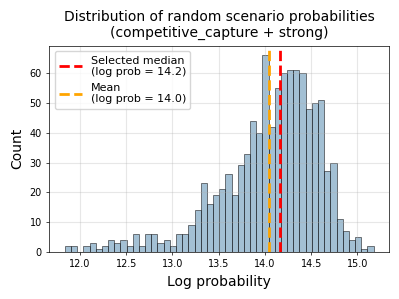


Comparison to single antigen scenarios:
  wuhan-only: log prob = 11.24 (-2.80 vs mean random)
  ba1-only: log prob = 12.06 (-1.98 vs mean random)
  ba4-only: log prob = 11.01 (-3.03 vs mean random)
  mixed: log prob = 12.61 (-1.43 vs mean random)


In [11]:
# ANALYZE RANDOM SCENARIO DISTRIBUTION

if QUICK_MODE or proba_random_from_file is None:
    print("\nSkipping random scenario analysis (not computed in QUICK_MODE)")
    median_random = None
    median_random_index = None
else:
    print("\nAnalyzing random scenario distribution...")
    
    # Find median random context
    
    # Calculate mean probability across bootstrap replicates for each random context
    random_means = np.mean(proba_random_from_file, axis=1)
    
    # Sort by probability
    random_means_sorted = sorted(range(len(random_means)), key=lambda x: random_means[x])
    
    # Get "median" index (actually slightly above median: +10 offset from paper)
    median_random_index = random_means_sorted[int(len(random_means)/2) + 10]
    median_random = contexts_random_from_file[median_random_index]
    
    print(f"\nMedian random scenario (index {median_random_index}):")
    print(f"  Context: {median_random}")
    print(f"  Log probability: {np.log(random_means[median_random_index]):.2f}")
    print(f"  Probability: {random_means[median_random_index]:.2e}")
    
    # Distribution statistics
    
    log_probs = np.log(random_means)
    
    print(f"\nRandom scenario statistics:")
    print(f"  Mean log-probability: {np.mean(log_probs):.2f}")
    print(f"  Median log-probability: {np.median(log_probs):.2f}")
    print(f"  Std log-probability: {np.std(log_probs):.2f}")
    print(f"  Min log-probability: {np.min(log_probs):.2f}")
    print(f"  Max log-probability: {np.max(log_probs):.2f}")
    
    # Overall mean across all bootstrap replicates
    overall_mean_log_prob = np.mean(np.log(proba_random_from_file))
    print(f"  Overall mean log-prob (all bootstraps): {overall_mean_log_prob:.2f}")
    
    # Plot histogram
    
    fig, ax = plt.subplots(1, 1, figsize=(4, 3))
    
    ax.hist(log_probs, bins=50, color='#7da6c2', alpha=0.7, edgecolor='black', linewidth=0.5)
    
    # Mark median
    ax.axvline(np.log(random_means[median_random_index]), 
               color='red', linestyle='--', linewidth=2, 
               label=f'Selected median\n(log prob = {np.log(random_means[median_random_index]):.1f})')
    
    # Mark mean
    ax.axvline(np.mean(log_probs), 
               color='orange', linestyle='--', linewidth=2,
               label=f'Mean\n(log prob = {np.mean(log_probs):.1f})')
    
    ax.set_xlabel('Log probability', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.set_title(f'Distribution of random scenario probabilities\n({fitness_model} + {selection_strength})', 
                 fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    
    # Save figure
    output_filename = f"{IMAGE_DIR}/random_distribution_{antibody}_{fitness_model}_{selection_strength}.png"
    plt.savefig(output_filename, dpi=300)
    print(f"\n✓ Histogram saved to: {output_filename}")
    
    plt.show()
    
    # Compare to single antigen scenarios
    
    print("\nComparison to single antigen scenarios:")
    for ag in antigens:
        single_scenario = tuple([ag] * L)
        if single_scenario in proba_from_file:
            single_prob = np.mean(proba_from_file[single_scenario])
            if single_prob > 0:
                print(f"  {ag}-only: log prob = {np.log(single_prob):.2f} "
                      f"({np.log(single_prob) - np.mean(log_probs):.2f} vs mean random)")
    
    # Compare to mixed scenario
    mixed_scenario = tuple(['mixed'] * L)
    if mixed_scenario in proba_from_file:
        mixed_prob = np.mean(proba_from_file[mixed_scenario])
        if mixed_prob > 0:
            print(f"  mixed: log prob = {np.log(mixed_prob):.2f} "
                  f"({np.log(mixed_prob) - np.mean(log_probs):.2f} vs mean random)")


In [12]:
# DEFINE CONTEXTS OF INTEREST FOR DETAILED ANALYSIS

print("\nDefining contexts of interest for detailed analysis...")

# NOTE: You should update the "optimal" scenario based on your actual results
# from Cell 5 (check the printed "Optimal scenario" or top of the sorted list)

if QUICK_MODE or median_random is None:
    print("  WARNING: median_random not computed (QUICK_MODE enabled)")
    print("  Using 'mixed' as placeholder for random_median")
    median_random_placeholder = ["mixed"] * L
else:
    median_random_placeholder = list(median_random)

# Define scenarios for analysis
antigen_contexts = {
    # OPTIMAL SEQUENTIAL SCENARIO
    # TODO: Update this based on your actual optimal scenario from Cell 5!
    "optimal": ["ba1"]*4 + ["ba4"]*6 + ["wuhan"]*3,
    
    # SINGLE ANTIGEN SCENARIOS
    "wuhan_only": ["wuhan"] * L,
    "ba1_only": ["ba1"] * L,
    "ba4_only": ["ba4"] * L,
    
    # MIXED SCENARIOS
    "average_mixed": ["mixed"] * L,
    "random_median": median_random_placeholder,
}

# Print summary
print("\nDefined scenarios:")
for name, context in antigen_contexts.items():
    # Summarize context (show transitions)
    context_summary = []
    current_ag = context[0]
    count = 1
    
    for ag in context[1:]:
        if ag == current_ag:
            count += 1
        else:
            context_summary.append(f"{current_ag}({count})")
            current_ag = ag
            count = 1
    context_summary.append(f"{current_ag}({count})")
    
    summary_str = " → ".join(context_summary)
    print(f"  {name:20s}: {summary_str}")

# VALIDATION

print("\nValidating scenarios...")

# Check that all scenarios have correct length
for name, context in antigen_contexts.items():
    if len(context) != L:
        print(f"  ERROR: '{name}' has length {len(context)}, expected {L}")
        raise ValueError(f"Scenario '{name}' has incorrect length")

# Check that all antigens are valid
valid_antigens = set(antigens + ['mixed', 'random'])
for name, context in antigen_contexts.items():
    invalid_antigens = set(context) - valid_antigens
    if invalid_antigens:
        print(f"  ERROR: '{name}' contains invalid antigens: {invalid_antigens}")
        raise ValueError(f"Scenario '{name}' contains invalid antigens")

print("✓ All scenarios validated")

# HELPER: Update optimal scenario interactively

print("\n" + "="*60)
print("IMPORTANT: Update the 'optimal' scenario!")
print("="*60)
print("The optimal scenario is currently a placeholder.")
print("Check the output from Cell 5 or Cell 6 to find your actual optimal scenario.")
print("\nTo update:")
print("1. Look at the 'Optimal scenario:' printed in previous cells")
print("2. Count how many steps of each antigen")
print("3. Update the line:")
print('   "optimal": ["wuhan"]*X + ["ba1"]*Y + ["ba4"]*Z,')
print("   where X+Y+Z = 13")
print("="*60)


Defining contexts of interest for detailed analysis...

Defined scenarios:
  optimal             : ba1(4) → ba4(6) → wuhan(3)
  wuhan_only          : wuhan(13)
  ba1_only            : ba1(13)
  ba4_only            : ba4(13)
  average_mixed       : mixed(13)
  random_median       : ba4(5) → wuhan(2) → ba1(1) → wuhan(1) → ba4(1) → ba1(1) → wuhan(1) → ba1(1)

Validating scenarios...
✓ All scenarios validated

IMPORTANT: Update the 'optimal' scenario!
The optimal scenario is currently a placeholder.
Check the output from Cell 5 or Cell 6 to find your actual optimal scenario.

To update:
1. Look at the 'Optimal scenario:' printed in previous cells
2. Count how many steps of each antigen
3. Update the line:
   "optimal": ["wuhan"]*X + ["ba1"]*Y + ["ba4"]*Z,
   where X+Y+Z = 13


## Determine the normalized probability of each mutation at each step for Figure 3d (strong selection not shown in Tharp et al, 2026)

In [13]:
# HELPER FUNCTIONS

def mutation(s, ii, L):
    """ Return the sequence (in int format) with base s,
        with a somatic mutation at pos ii """
    return s | 2**(L-1-ii)

def nb_mutation(s):
    """ Number of mutations in variant s """
    return bin(s).count("1")

def reachable(s, L):
    return [(s | 2**ii) for ii in range(L) if (s | 2**ii) > s]



# CALCULATE MUTATION ORDER PROBABILITIES

print("\nCalculating mutation order probabilities for each scenario...")

for ac in tqdm(antigen_contexts, desc="Scenarios"):
    print(f"\n  Processing scenario: {ac}")
    
    # Precompute transition probability matrices to every power
    # pmut_power[i] = product of first i transition matrices
    # This represents the probability of reaching any sequence after i steps
    
    pmut_power = {}
    pmut_power[0] = sp.sparse.identity(2**L, format='csr')  # Identity for 0 steps
    
    for i in range(1, L + 1):
        # Get the antigen context at step i (0-indexed)
        ag_at_step = antigen_contexts[ac][i-1]
        pmut_power[i] = pmut_power[i-1] @ pmut_normed[ag_at_step]
    
    # Create "force mutation" matrices
    # force_mut[(step, mut)] forces mutation 'mut' to occur at 'step'
    # All other mutations at that step have probability 0
    
    force_mut = {}
    
    for mut in range(L):
        for step in range(L):
            force_mut[(step, mut)] = dok_matrix((2**L, 2**L), dtype=np.float64)
        
        # For each source sequence
        for s in sequences_int[:-1]:  # Exclude somatic (already has all mutations)
            nb_mut_s = nb_mutation(s)
            
            # Target sequence after adding mutation 'mut'
            target = mutation(s, mut, L)  # CHANGED: renamed from 't' to 'target'
            
            # Only allow this specific mutation at this step
            # Use the normalized probability from the appropriate antigen context
            ag_at_step = antigen_contexts[ac][nb_mut_s]
            force_mut[(nb_mut_s, mut)][s, target] = pmut_normed[ag_at_step][s, target]  # CHANGED
        
        # Convert to CSR for efficient multiplication
        for step in range(L):
            force_mut[(step, mut)] = force_mut[(step, mut)].tocsr()
    
    # Calculate mutation order probabilities (Equation 17 - numerator)
    # proba[mut, t] = probability that mutation 'mut' occurs at step 't'
    
    proba = np.zeros((L, L))
    
    for mut in range(L):
        for t in range(1, L + 1):
            # Probability = (reach step t-1) × (force mut at step t) × (reach somatic from step t)
            # Matrix multiplication: [germline row] → [through t-1 steps] → [force mut] → [through remaining steps] → [somatic column]
            result = pmut_power[t-1] @ force_mut[(t-1, mut)] @ pmut_power[L - t]
            proba[mut, t-1] = result[0, 2**L - 1]  # Extract germline→somatic probability
    
    # NORMALIZE: Each column should sum to 1 (Equation 17 - full formula)
    # This ensures: given that we're at step t, the probabilities
    # of all possible mutations sum to 1
    
    for t in range(L):
        column_sum = proba[:, t].sum()
        if column_sum > 1e-100:  # Use small threshold to avoid division by zero
            proba[:, t] = proba[:, t] / column_sum
        else:
            # If column sum is essentially 0, leave as zeros
            print(f"    ⚠ Warning: Step {t+1} has zero total probability (no viable paths)")
    
    # Save results to CSV
    
    # Create column names
    order_columns = [f"Order {i+1}" for i in range(L)]
    mutation_labels = [f"Mut {i+1}" for i in range(L)]
    
    # Create DataFrame
    proba_df = pd.DataFrame(proba, columns=order_columns)
    proba_df['Mutation'] = mutation_labels
    
    # Reorder columns to put Mutation first
    proba_df = proba_df[['Mutation'] + order_columns]
    
    # Save to file
    output_filename = f"{DATA_DIR}/{antibody}_probability_{ac}_{fitness_model}_{selection_strength}.csv"
    proba_df.to_csv(output_filename, index=False)
    print(f"    ✓ Saved to: {output_filename}")
    
    # Show summary statistics
    print(f"    Mutation order probability range: [{proba.min():.4f}, {proba.max():.4f}]")
    print(f"    Sum of probabilities per order: {proba.sum(axis=0)[:3]} ... (should be ~1.0 for each)")
    
    # Verify normalization
    max_deviation = np.max(np.abs(proba.sum(axis=0) - 1.0))
    if max_deviation > 1e-10:
        print(f"    ⚠ Warning: Max deviation from 1.0 is {max_deviation:.2e}")

print("\n✓ Mutation order probability calculations complete")


Calculating mutation order probabilities for each scenario...


Scenarios:   0%|          | 0/6 [00:00<?, ?it/s]


  Processing scenario: optimal


Scenarios:  17%|█▋        | 1/6 [00:00<00:03,  1.26it/s]

    ✓ Saved to: competitive_antigen_capture/strong_norm_data/omi-32_probability_optimal_competitive_capture_strong.csv
    Mutation order probability range: [0.0000, 0.5060]
    Sum of probabilities per order: [1. 1. 1.] ... (should be ~1.0 for each)

  Processing scenario: wuhan_only


...

    ✓ Saved to: competitive_antigen_capture/strong_norm_data/omi-32_probability_ba4_only_competitive_capture_strong.csv
    Mutation order probability range: [0.0000, 0.7702]
    Sum of probabilities per order: [1. 1. 1.] ... (should be ~1.0 for each)

  Processing scenario: average_mixed


Scenarios:  83%|████████▎ | 5/6 [00:03<00:00,  1.25it/s]

    ✓ Saved to: competitive_antigen_capture/strong_norm_data/omi-32_probability_average_mixed_competitive_capture_strong.csv
    Mutation order probability range: [0.0000, 0.5446]
    Sum of probabilities per order: [1. 1. 1.] ... (should be ~1.0 for each)

  Processing scenario: random_median


Scenarios: 100%|██████████| 6/6 [00:04<00:00,  1.25it/s]

    ✓ Saved to: competitive_antigen_capture/strong_norm_data/omi-32_probability_random_median_competitive_capture_strong.csv
    Mutation order probability range: [0.0000, 0.5273]
    Sum of probabilities per order: [1. 1. 1.] ... (should be ~1.0 for each)

✓ Mutation order probability calculations complete


## Figure 3e - strong selection not shown in Tharp et al, 2026


Calculating variant probabilities for ba1_only scenario...

Processing context: ba1_only


100%|██████████| 8192/8192 [00:00<00:00, 107819.27it/s]


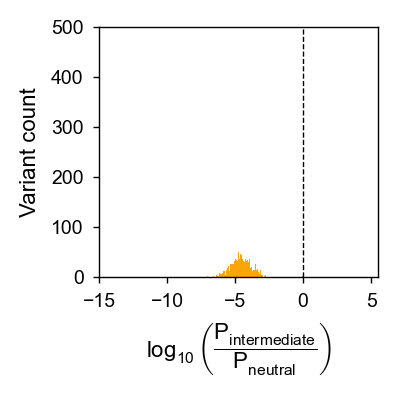


Main FDL plot:
  Canvas size: 1 × 1 inches
  Total figure size: 1.20 × 1.20 inches
  At 2000 DPI: 2400 × 2400 pixels


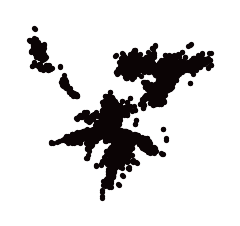


Colorbar:
  Canvas size: 0.075 × 1.0 inches
  Total figure size: 1.18 × 1.52 inches
  At 2000 DPI: 2350 × 3050 pixels


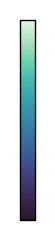


✓ Variant probability analysis complete


In [14]:
# Set font to Arial
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.it'] = 'Arial:italic'
plt.rcParams['mathtext.bf'] = 'Arial:bold'

# CALCULATE AND PLOT VARIANT PROBABILITIES

from matplotlib.colors import LinearSegmentedColormap

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    if isinstance(cmap, str):
        cmap = plt.get_cmap(cmap)
    new_cmap = LinearSegmentedColormap.from_list(
        f'trunc({cmap.name},{minval:.2f},{maxval:.2f})',
        cmap(np.linspace(minval, maxval, n))
    )
    return new_cmap

print("\nCalculating variant probabilities for ba1_only scenario...")

for context in [s for s in SCENARIOS_TO_ANALYZE if s in antigen_contexts]:
    print(f"\nProcessing context: {context}")
    antigen_context = antigen_contexts[context]

    if selection_strength == 'strong':
        pmut_to_use = pmut_unnormed_mean
    else:
        pmut_to_use = pmut_normed

    A = {0: sp.sparse.identity(2**L, format='csr')}
    B = {0: sp.sparse.identity(2**L, format='csr')}

    for ii in range(1, L + 1):
        A[ii] = A[ii-1] @ pmut_to_use[antigen_context[ii-1]]

    for ii in range(1, L + 1):
        B[ii] = pmut_to_use[antigen_context[L-ii]] @ B[ii-1]

    # Variant probabilities

    proba = np.zeros(2**L)
    norm = defaultdict(int)

    for v in tqdm(sequences_int):
        if v != 0 and v != 2**L - 1:
            n = nb_mutation(v)
            proba[v] = A[n][0,v] * B[L-n][v,2**L-1]
            norm[n] += 1

    for v in sequences_int:
        n = nb_mutation(v)
        if selection_strength == 'strong':
            proba[v] = proba[v] * norm[n] / math.factorial(L)
        else:
            proba[v] = proba[v] * norm[n]

    proba[0] = 1.0
    proba[2**L - 1] = 1.0

    # HISTOGRAM

    mpl.rcParams['figure.dpi'] = 200
    indices = np.where(proba > 0)[0]

    if selection_strength != 'strong':
        probas_for_plot = np.log10(proba[indices])
    else:
        probas_for_plot = np.log10(proba[indices] + 1e-100)

    probas_for_plot[probas_for_plot < -50] = -50

    fig, ax = plt.subplots(figsize=(2,2))
    plt.hist(probas_for_plot, bins=100, color=cm.inferno_r(0.2))
    plt.plot([0,0],[0,10000],'k--',linewidth=0.5)

    plt.ylim([0,500])
    plt.xlim([-15,5.5])
    plt.xticks([-15,-10,-5,0,5])
    plt.xlabel(r'$\log_{10}\left(\dfrac{P_{intermediate}}{P_{neutral}}\right)$', fontsize=8)
    plt.ylabel('Variant count', fontsize=8)

    plt.tight_layout()
    plt.savefig(f'{IMAGE_DIR}/variantdist_{antibody}_{context}_{fitness_model}_{selection_strength}.png', transparent=True)
    plt.show()

    # FDL PLOT + SEPARATE COLORBAR

    fdl_filename = f"../force-directed-layouts/data/Omi32.csv"

    try:
        df_fdl = pd.read_csv(fdl_filename, dtype={"variant":"str"})
        df_fdl["variant_int"] = df_fdl.variant.apply(lambda x: int(x,2))
        df_fdl = df_fdl.set_index("variant_int").reindex(range(0,2**L)).reset_index()
        df_fdl["path_prob"] = proba
        df_fdl = df_fdl.sort_values(by="path_prob")

        # ---------------- USER CONTROLS ----------------
        # Main FDL plot canvas size (original figsize)
        FDL_CANVAS_WIDTH = 1
        FDL_CANVAS_HEIGHT = 1
        
        # Main FDL plot margins
        FDL_LEFT_MARGIN = 0.1
        FDL_RIGHT_MARGIN = 0.1
        FDL_TOP_MARGIN = 0.1
        FDL_BOTTOM_MARGIN = 0.1
        
        FDL_DPI = 2000

        # Colorbar canvas sizing in INCHES
        CBAR_CANVAS_WIDTH  = 0.075
        CBAR_CANVAS_HEIGHT = 1.0

        # Colorbar margins
        CBAR_LEFT_MARGIN   = 0.1
        CBAR_RIGHT_MARGIN  = 1
        CBAR_TOP_MARGIN    = 0.175
        CBAR_BOTTOM_MARGIN = 0.35

        CBAR_DPI = 2000

        # Updated color scale: 1 to 100 (log10 scale)
        minval = 1.0
        maxval = 100.0

        cmap = plt.get_cmap('mako')
        new_cmap = truncate_colormap(cmap, 0.1, 1)
        norm = mpl.colors.Normalize(vmin=np.log10(minval), vmax=np.log10(maxval))

        # ---- MAIN FDL ----
        # Calculate total figure size
        fdl_fig_width = FDL_LEFT_MARGIN + FDL_CANVAS_WIDTH + FDL_RIGHT_MARGIN
        fdl_fig_height = FDL_TOP_MARGIN + FDL_CANVAS_HEIGHT + FDL_BOTTOM_MARGIN
        
        fig = plt.figure(figsize=(fdl_fig_width, fdl_fig_height))
        
        # Create axis using margins
        ax_left = FDL_LEFT_MARGIN / fdl_fig_width
        ax_bottom = FDL_BOTTOM_MARGIN / fdl_fig_height
        ax_width = FDL_CANVAS_WIDTH / fdl_fig_width
        ax_height = FDL_CANVAS_HEIGHT / fdl_fig_height
        
        ax = fig.add_axes([ax_left, ax_bottom, ax_width, ax_height])

        ax.scatter(-df_fdl.fdl_x, -df_fdl.fdl_y,
                   s=0.8, color=cmap(0.0))

        mask = df_fdl.path_prob > minval
        ax.scatter(-df_fdl.loc[mask,'fdl_x'],
                   -df_fdl.loc[mask,'fdl_y'],
                   s=0.4,
                   c=np.log10(df_fdl.loc[mask,'path_prob']),
                   cmap=new_cmap,
                   norm=norm)

        ax.set_aspect('equal')
        ax.set_axis_off()

        # Print main FDL figure size information
        print(f'\nMain FDL plot:')
        print(f'  Canvas size: {FDL_CANVAS_WIDTH} × {FDL_CANVAS_HEIGHT} inches')
        print(f'  Total figure size: {fdl_fig_width:.2f} × {fdl_fig_height:.2f} inches')
        print(f'  At {FDL_DPI} DPI: {int(fdl_fig_width * FDL_DPI)} × {int(fdl_fig_height * FDL_DPI)} pixels')

        plt.savefig(
            f'{IMAGE_DIR}/landscape_paths_{antibody}_{context}_{fitness_model}_{selection_strength}.png',
            dpi=FDL_DPI,
            transparent=True
        )
        plt.savefig(
            f'{IMAGE_DIR}/landscape_paths_{antibody}_{context}_{fitness_model}_{selection_strength}.pdf',
            transparent=True
        )
        plt.show()

        # ---- COLORBAR ONLY ----
        cbar_fig_width = CBAR_LEFT_MARGIN + CBAR_CANVAS_WIDTH + CBAR_RIGHT_MARGIN
        cbar_fig_height = CBAR_TOP_MARGIN + CBAR_CANVAS_HEIGHT + CBAR_BOTTOM_MARGIN

        fig_cb = plt.figure(figsize=(cbar_fig_width, cbar_fig_height))

        # Axis rectangle in figure fractions
        ax_left   = CBAR_LEFT_MARGIN / cbar_fig_width
        ax_bottom = CBAR_BOTTOM_MARGIN / cbar_fig_height
        ax_width  = CBAR_CANVAS_WIDTH / cbar_fig_width
        ax_height = CBAR_CANVAS_HEIGHT / cbar_fig_height

        cax = fig_cb.add_axes([ax_left, ax_bottom, ax_width, ax_height])

        sm = mpl.cm.ScalarMappable(norm=norm, cmap=new_cmap)
        sm.set_array([])

        # Major ticks at 10^0, 10^1, 10^2 (i.e., log10 values 0, 1, 2)
        cbar = fig_cb.colorbar(sm, cax=cax, ticks=[0, 1, 2])
        # Minor tick at 10^0.5 (i.e., log10 value 0.5)
        #cax.yaxis.set_minor_locator(mpl.ticker.FixedLocator([0.5]))
        
        cbar.ax.set_yticklabels(['$10^0$', '$10^1$', '$10^2$'])
        cbar.ax.tick_params(labelsize=7, which='major', length=2, width=0.5)
        cbar.ax.tick_params(which='minor', length=1.5, width=0.5)

        cbar.ax.set_ylabel(
            r'$\dfrac{P_{intermediate}}{P_{neutral}}$',
            rotation=0,
            fontsize=8,
            labelpad=25,
            y=0.65
        )

        # Print colorbar figure size information
        print(f'\nColorbar:')
        print(f'  Canvas size: {CBAR_CANVAS_WIDTH} × {CBAR_CANVAS_HEIGHT} inches')
        print(f'  Total figure size: {cbar_fig_width:.2f} × {cbar_fig_height:.2f} inches')
        print(f'  At {CBAR_DPI} DPI: {int(cbar_fig_width * CBAR_DPI)} × {int(cbar_fig_height * CBAR_DPI)} pixels')

        plt.savefig(
            f'{IMAGE_DIR}/landscape_paths_colorbar_{antibody}_{context}_{fitness_model}_{selection_strength}.png',
            dpi=CBAR_DPI,
            transparent=True
        )
        plt.savefig(
            f'{IMAGE_DIR}/landscape_paths_colorbar_{antibody}_{context}_{fitness_model}_{selection_strength}.pdf',
            transparent=True
        )
        cbar.ax.set_ylabel('')
        plt.savefig(
            f'{IMAGE_DIR}/landscape_paths_colorbar_nolabel_{antibody}_{context}_{fitness_model}_{selection_strength}.png',
            dpi=CBAR_DPI,
            transparent=True
        )
        plt.savefig(
            f'{IMAGE_DIR}/landscape_paths_colorbar_nolabel_{antibody}_{context}_{fitness_model}_{selection_strength}.pdf',
            transparent=True
        )
        cbar.ax.set_yticks([])
        plt.savefig(f'{IMAGE_DIR}/landscape_paths_colorbar_ticks_nolabel.png', dpi=CBAR_DPI, transparent=True)
        plt.savefig(f'{IMAGE_DIR}/landscape_paths_colorbar_ticks_nolabel.pdf', transparent=True)
        plt.show()

    except Exception as e:
        print(f"⚠ FDL plotting skipped: {e}")

print("\n✓ Variant probability analysis complete")

In [15]:
# FIND MOST LIKELY EVOLUTIONARY PATHS
# (With optimized sampling + exhaustive fallback for strong selection)

print("\nFinding most likely evolutionary paths for each scenario...")

# Prepare fitness dictionaries

print("Preparing fitness dictionaries...")
fitnesses = {}

for ag in antigens + ['mixed']:
    # Calculate fitness using our unified function (handles all fitness models)
    fitness_array = calculate_fitness(ag, bootstrap_replicate=None)
    fitnesses[ag] = {i: fitness_array[i] for i in range(len(fitness_array))}

# Add mutation count column if not already present
if "nb_mutation" not in df.columns:
    df["nb_mutation"] = df.variant_int.apply(nb_mutation)

# Configuration

# uses NUM_BEST_PATHS from Cell 0

# Store results
best_paths = {}

# OPTIMIZED SAMPLING FOR STRONG SELECTION

def precompute_viability(antigen_context, pmut_unnormed_dict, L):
    """
    Pre-compute which sequences can reach somatic via uphill paths.
    
    This works BACKWARDS from somatic, marking which sequences are viable.
    Done ONCE per scenario, then used for fast sampling.
    
    Returns:
    - viable: dict mapping (sequence, num_mutations) -> bool
    - viable_neighbors: dict mapping (sequence, num_mutations) -> list of viable uphill neighbors
    """
    
    print("    Pre-computing viable sequences (backwards from somatic)...")
    
    viable = {}
    viable_neighbors = {}
    
    # Start from somatic (always viable by definition)
    somatic = 2**L - 1
    viable[(somatic, L)] = True
    viable_neighbors[(somatic, L)] = []
    
    # Work backwards from L-1 mutations down to 0 (germline)
    for num_muts in tqdm(range(L - 1, -1, -1), desc="      Computing viability", leave=False):
        
        # For each sequence with num_muts mutations
        for s in sequences_int:
            if nb_mutation(s) != num_muts:
                continue
            
            ag_at_step = antigen_context[num_muts]
            
            # Find uphill neighbors that can reach somatic
            uphill_viable_neighbors = []
            for t in reachable(s, L):
                fix_prob = pmut_unnormed_dict[ag_at_step][s, t]
                
                if fix_prob > 0.5:  # Uphill (for strong selection, this is 1.0)
                    # Check if this neighbor can reach somatic
                    nb_muts_t = nb_mutation(t)
                    if viable.get((t, nb_muts_t), False):
                        uphill_viable_neighbors.append(t)
            
            # This sequence is viable if it has at least one viable uphill neighbor
            is_viable = len(uphill_viable_neighbors) > 0
            viable[(s, num_muts)] = is_viable
            viable_neighbors[(s, num_muts)] = uphill_viable_neighbors
    
    # Count viable sequences
    n_viable = sum(1 for v in viable.values() if v)
    total_sequences = 2**L
    print(f"      ✓ Found {n_viable:,} viable sequences (out of {total_sequences:,})")
    
    return viable, viable_neighbors


def sample_uphill_path_fast(viable_neighbors, L):
    """
    Sample one random uphill path using pre-computed viability.
    
    This is MUCH faster than trial-and-error because we only
    choose from neighbors we KNOW can reach somatic.
    
    Returns:
    - path: list of L+1 sequence integers
    """
    
    path = [0]  # Start at germline
    current = 0
    
    for step in range(L):
        nb_mut_current = nb_mutation(current)
        
        # Get pre-computed viable uphill neighbors
        neighbors = viable_neighbors.get((current, nb_mut_current), [])
        
        if len(neighbors) == 0:
            # This should never happen if germline is viable
            raise RuntimeError(f"Dead end at sequence {current} with {nb_mut_current} mutations")
        
        # Choose random viable neighbor (all guaranteed to reach somatic)
        next_seq = np.random.choice(neighbors)
        path.append(next_seq)
        current = next_seq
    
    return path


def sample_multiple_paths_fast(antigen_context, pmut_unnormed_dict, L, num_paths):
    """
    Sample multiple uphill paths efficiently.
    
    Strategy:
    1. Pre-compute viability ONCE (slow but only done once)
    2. Sample paths using pre-computed info (fast, repeated many times)
    
    Returns:
    - paths: numpy array of shape (num_paths, L+1)
    """
    
    # Step 1: Pre-compute viability (ONCE)
    viable, viable_neighbors = precompute_viability(antigen_context, pmut_unnormed_dict, L)
    
    # Check if germline is viable
    if not viable.get((0, 0), False):
        print("      ⚠ Germline cannot reach somatic via viability check")
        return np.empty((0, L + 1), dtype=int), viable_neighbors
    
    # Step 2: Sample paths (FAST - no failures!)
    print(f"    Sampling {num_paths:,} paths...")
    
    sampled_paths = []
    
    for i in tqdm(range(num_paths), desc="      Sampling paths", leave=False):
        path = sample_uphill_path_fast(viable_neighbors, L)
        sampled_paths.append(path)
    
    return np.array(sampled_paths), viable_neighbors


def enumerate_all_uphill_paths(antigen_context, pmut_unnormed_dict, L, max_paths=1000):
    """
    EXHAUSTIVE ENUMERATION: Find ALL uphill paths from germline to somatic.
    
    This is a FALLBACK when viability check fails but we suspect paths might exist
    (e.g., due to numerical issues or edge cases).
    
    WARNING: Can be slow if many paths exist! Use max_paths to limit.
    
    Returns:
    - paths: list of paths (each path is a list of L+1 sequences)
    """
    
    print("    ⚠ FALLBACK: Exhaustively enumerating all uphill paths...")
    print(f"      (Limited to first {max_paths:,} paths found)")
    
    all_paths = []
    
    def dfs_enumerate(current_path, current_seq):
        """Depth-first search to enumerate all uphill paths."""
        
        # Stop if we've found enough paths
        if len(all_paths) >= max_paths:
            return
        
        # Base case: reached somatic
        if current_seq == 2**L - 1:
            all_paths.append(current_path.copy())
            return
        
        # Get current step
        nb_mut_current = nb_mutation(current_seq)
        ag_at_step = antigen_context[nb_mut_current]
        
        # Try all uphill neighbors
        for next_seq in reachable(current_seq, L):
            fix_prob = pmut_unnormed_dict[ag_at_step][current_seq, next_seq]
            
            if fix_prob > 0.5:  # Uphill
                # Recursively explore this branch
                current_path.append(next_seq)
                dfs_enumerate(current_path, next_seq)
                current_path.pop()  # Backtrack
    
    # Start DFS from germline
    dfs_enumerate([0], 0)
    
    print(f"      ✓ Found {len(all_paths):,} uphill paths")
    
    return all_paths


# Find paths for each scenario

# You can analyze all scenarios or just specific ones
## uses SCENARIOS_TO_ANALYZE from Cell 0  # Uncomment to analyze subset

for ac in tqdm(SCENARIOS_TO_ANALYZE, desc="Finding paths"):
    
    print(f"\n  Scenario: {ac}")
    
    # BRANCH: Strong vs Moderate/Weak Selection
    
    if selection_strength == 'strong':
        # STRONG SELECTION: Optimized random uphill path sampling
        
        print(f"    Strong selection: Sampling {NUM_BEST_PATHS} random uphill paths...")
        
        sampled_paths_array, viable_neighbors = sample_multiple_paths_fast(
            antigen_contexts[ac],
            pmut_unnormed_mean,  # mean landscape, keyed by ag string
            L,
            num_paths=NUM_BEST_PATHS
        )
        
        # FALLBACK: Exhaustive enumeration if no paths found
        
        if len(sampled_paths_array) == 0:
            print(f"    ⚠ No uphill paths found via viability check")
            print(f"    → Attempting exhaustive enumeration as fallback...")
            
            # Try exhaustive enumeration
            all_paths_list = enumerate_all_uphill_paths(
                antigen_contexts[ac],
                pmut_unnormed_mean,  # mean landscape, keyed by ag string
                L,
                max_paths=10000  # Limit to prevent infinite search
            )
            
            if len(all_paths_list) == 0:
                print(f"    ✗ CONFIRMED: No uphill paths exist from germline to somatic!")
                print(f"      This scenario is evolutionarily inaccessible under strong selection")
                best_paths[ac] = np.empty((0, L + 1), dtype=int)
            
            elif len(all_paths_list) <= NUM_BEST_PATHS:
                # Found some paths, but fewer than requested
                print(f"    ✓ Found {len(all_paths_list)} uphill paths (all of them)")
                print(f"      Using all {len(all_paths_list)} paths (fewer than requested {NUM_BEST_PATHS})")
                best_paths[ac] = np.array(all_paths_list)
            
            else:
                # Found many paths - sample randomly from them
                print(f"    ✓ Found {len(all_paths_list)} uphill paths")
                print(f"      Randomly sampling {NUM_BEST_PATHS} from enumerated paths")
                
                # Sample without replacement
                sampled_indices = np.random.choice(len(all_paths_list), 
                                                  size=NUM_BEST_PATHS, 
                                                  replace=False)
                sampled_paths = [all_paths_list[i] for i in sampled_indices]
                best_paths[ac] = np.array(sampled_paths)
        
        else:
            best_paths[ac] = sampled_paths_array
            print(f"    ✓ Sampled {len(sampled_paths_array):,} random uphill paths")
    
    else:
        # MODERATE/WEAK SELECTION: Use k-shortest paths
        
        print(f"    Moderate/weak selection: Finding {NUM_BEST_PATHS} most likely paths...")
        
        # Create directed weighted graph
        G = nx.DiGraph()
        G.add_nodes_from(sequences_int)
        
        # Add weighted edges
        edges = []
        for s in sequences_int:
            nb_mut_s = nb_mutation(s)
            
            # Skip if we're at the somatic sequence (no outgoing edges)
            if nb_mut_s >= L:
                continue
            
            ag_at_step = antigen_contexts[ac][nb_mut_s]
            
            for t in reachable(s, L):
                # Get fixation probability from unnormalized matrix
                fix_prob = pmut_unnormed_mean[ag_at_step][s, t]
                
                # Edge weight = -log(probability)
                # Add small epsilon to avoid log(0)
                weight = -np.log(fix_prob + 1e-100)
                
                edges.append((s, t, weight))
        
        G.add_weighted_edges_from(edges)
        
        print(f"    Graph has {G.number_of_nodes():,} nodes and {G.number_of_edges():,} edges")
        
        # Find k shortest paths
        best_paths[ac] = np.empty((NUM_BEST_PATHS, L + 1), dtype=int)
        
        try:
            i = 0
            for path in k_shortest_paths(G, 0, 2**L - 1, NUM_BEST_PATHS, weight='weight'):
                best_paths[ac][i] = path
                i += 1
                
            print(f"    ✓ Found {i} paths")
            
            # Calculate path probabilities (for reporting)
            path_probs = []
            for path_idx in range(min(5, i)):  # Show top 5
                path = best_paths[ac][path_idx]
                log_prob = 0
                for step in range(L):
                    s, t = path[step], path[step + 1]
                    nb_mut_s = nb_mutation(s)
                    ag_at_step = antigen_contexts[ac][nb_mut_s]
                    fix_prob = pmut_unnormed_mean[ag_at_step][s, t]
                    log_prob += np.log(fix_prob + 1e-100)
                path_probs.append(log_prob)
            
            print(f"    Top 5 path log-probabilities: {[f'{p:.2f}' for p in path_probs[:5]]}")
            
        except nx.NetworkXNoPath:
            print(f"    ⚠ No path exists from germline to somatic!")
            best_paths[ac] = np.empty((0, L + 1), dtype=int)


# DIAGNOSTIC: Count total uphill paths (strong selection only)

if selection_strength == 'strong':
    print("\n" + "="*60)
    print("COUNTING TOTAL UPHILL PATHS (Strong Selection)")
    print("="*60)
    
    def count_uphill_paths_recursive(s, ag_context, memo=None):
        """Recursively count all uphill paths from sequence s to somatic."""
        if memo is None:
            memo = {}
        
        if s in memo:
            return memo[s]
        
        # Base case: reached somatic
        if s == 2**L - 1:
            return 1
        
        # Recursive case: count paths through each uphill neighbor
        nb_mut_s = nb_mutation(s)
        
        # Check we're not beyond L mutations
        if nb_mut_s >= L:
            memo[s] = 0
            return 0
        
        ag_at_step = ag_context[nb_mut_s]
        
        total = 0
        for neighbor in reachable(s, L):
            fix_prob = pmut_unnormed_mean[ag_at_step][s, neighbor]
            if fix_prob > 0.5:  # Uphill (for strong selection, this is 1.0)
                total += count_uphill_paths_recursive(neighbor, ag_context, memo)
        
        memo[s] = total
        return total
    
    print("\nTotal number of uphill paths for each scenario:")
    for ac in SCENARIOS_TO_ANALYZE:
        if ac in antigen_contexts:
            try:
                n_paths = count_uphill_paths_recursive(0, antigen_contexts[ac])
                
                if n_paths > 0:
                    print(f"  {ac:20s}: {n_paths:,} paths")
                    
                    # Calculate what fraction we sampled
                    n_sampled = len(best_paths.get(ac, []))
                    if n_sampled > 0:
                        fraction = n_sampled / n_paths * 100
                        print(f"    {'':20s}  (sampled {n_sampled:,}/{n_paths:,} = {fraction:.2f}%)")
                else:
                    print(f"  {ac:20s}: 0 paths (no viable evolutionary trajectory)")
            except Exception as e:
                print(f"  {ac:20s}: Error counting - {e}")
    
    print("="*60)

print("\n✓ Path finding complete")


Finding most likely evolutionary paths for each scenario...
Preparing fitness dictionaries...


Finding paths:   0%|          | 0/1 [00:00<?, ?it/s]


  Scenario: ba1_only
    Strong selection: Sampling 1000 random uphill paths...
    Pre-computing viable sequences (backwards from somatic)...


      ✓ Found 1,813 viable sequences (out of 8,192)
    Sampling 1,000 paths...


Finding paths: 100%|██████████| 1/1 [00:00<00:00,  3.26it/s]


    ✓ Sampled 1,000 random uphill paths

COUNTING TOTAL UPHILL PATHS (Strong Selection)

Total number of uphill paths for each scenario:
  ba1_only            : 77,233 paths
                          (sampled 1,000/77,233 = 1.29%)

✓ Path finding complete


## Determine uphill mutational steps for Supplemental Figure 3b

In [16]:
# BOOTSTRAP EDGE OVERLAP ANALYSIS
# For each bootstrap replicate nb, and for each scenario in
# SCENARIOS_TO_ANALYZE, we compute which directed edges (s -> t)
# are uphill under the current fitness_model. An edge is uphill
# if get_fixation_probability returns > 0 (for strong selection,
# this means fitness_t > fitness_s).
# The result is saved as a CSV with one row per edge (s, t) and
# columns:
#   - from_genotype   : source genotype integer
#   - to_genotype     : target genotype integer
#   - from_binary     : source as L-bit binary string
#   - to_binary       : target as L-bit binary string
#   - mutation_index  : which of the L positions was mutated (0-based)
#   - nb_mutations_from: number of mutations already in source genotype
#   - is_uphill       : 1 if edge is uphill in this bootstrap, 0 otherwise
# Filename pattern:
#   strong_data/{antibody}_edges_{scenario}_{fitness_model}_{selection_strength}_bootstrap{nb}.csv
# To compute overlap across models: load the same bootstrap index
# from each model run, join on (from_genotype, to_genotype), and
# compare is_uphill columns. Mean +/- SEM across bootstrap indices
# gives uncertainty on the overlap.

import os
os.makedirs(DATA_DIR, exist_ok=True)

print("\nComputing per-bootstrap edge overlap data...")
print(f"  fitness_model      : {fitness_model}")
print(f"  selection_strength : {selection_strength}")
print(f"  Nbootstrap         : {Nbootstrap}")
print(f"  Scenarios          : {SCENARIOS_TO_ANALYZE}")

# Pre-build the full edge list once (same for all bootstraps / models)
# Each entry is (s, t, mutation_index, nb_mutations_from_s)
all_edges = []
for s in sequences_int:
    nb_mut_s = nb_mutation(s)
    for t in reachable(s, L):
        # Which bit position changed? (the single bit that differs)
        diff = t ^ s
        mut_idx = int(np.log2(diff))
        all_edges.append((s, t, mut_idx, nb_mut_s))

print(f"  Total possible directed edges: {len(all_edges):,}")

for ac in SCENARIOS_TO_ANALYZE:
    print(f"\n  Scenario: {ac}")
    antigen_context = antigen_contexts[ac]

    for nb in range(Nbootstrap):

        # Build uphill set from per-bootstrap transition matrix.
        # pmut_unnormed[ag, nb][s, t] > 0 iff the edge is uphill
        # (for strong selection this is exactly fix_prob = 1.0 or 0.0).
        rows = []
        for s, t, mut_idx, nb_mut_s in all_edges:
            ag_at_step = antigen_context[nb_mut_s]
            fix_prob = pmut_unnormed[ag_at_step, nb][s, t]
            is_uphill = 1 if fix_prob > 0 else 0
            rows.append({
                'from_genotype'    : s,
                'to_genotype'      : t,
                'from_binary'      : format(s, f'0{L}b'),
                'to_binary'        : format(t, f'0{L}b'),
                'mutation_index'   : mut_idx,
                'nb_mutations_from': nb_mut_s,
                'is_uphill'        : is_uphill,
            })

        edge_df = pd.DataFrame(rows)

        # Summary for this replicate
        n_uphill = edge_df['is_uphill'].sum()
        n_total  = len(edge_df)
        print(f"    bootstrap {nb:02d}: {n_uphill:,} / {n_total:,} edges uphill "
              f"({100 * n_uphill / n_total:.1f}%)")

        out_fn = (f"{DATA_DIR}/{antibody}_edges_{ac}"
                  f"_{fitness_model}_{selection_strength}_bootstrap{nb}.csv")
        edge_df.to_csv(out_fn, index=False)

    print(f"  ✓ Saved {Nbootstrap} edge CSVs for {ac}")

print("\n✓ Edge overlap analysis complete")
print("\nTo compare across models, load the same bootstrap index from each")
print("model run and join on (from_genotype, to_genotype):")
print("  affinity_nb0  = pd.read_csv('...affinity...bootstrap0.csv')")
print("  capture_nb0   = pd.read_csv('...capture...bootstrap0.csv')")
print("  merged = affinity_nb0.merge(capture_nb0,")
print("               on=['from_genotype','to_genotype'],")
print("               suffixes=('_aff','_cap'))")
print("  overlap = (merged['is_uphill_aff'] & merged['is_uphill_cap']).sum()")



Computing per-bootstrap edge overlap data...
  fitness_model      : competitive_capture
  selection_strength : strong
  Nbootstrap         : 10
  Scenarios          : ['ba1_only']
  Total possible directed edges: 53,248

  Scenario: ba1_only
    bootstrap 00: 34,117 / 53,248 edges uphill (64.1%)
    bootstrap 01: 34,102 / 53,248 edges uphill (64.0%)
    bootstrap 02: 34,288 / 53,248 edges uphill (64.4%)
    bootstrap 03: 34,090 / 53,248 edges uphill (64.0%)
    bootstrap 04: 34,123 / 53,248 edges uphill (64.1%)
    bootstrap 05: 34,029 / 53,248 edges uphill (63.9%)
    bootstrap 06: 34,115 / 53,248 edges uphill (64.1%)
    bootstrap 07: 34,228 / 53,248 edges uphill (64.3%)
    bootstrap 08: 34,091 / 53,248 edges uphill (64.0%)
    bootstrap 09: 34,198 / 53,248 edges uphill (64.2%)
  ✓ Saved 10 edge CSVs for ba1_only

✓ Edge overlap analysis complete

To compare across models, load the same bootstrap index from each
model run and join on (from_genotype, to_genotype):
  affinity_nb0  = 

## Extract phenotypes along paths

In [17]:
# EXTRACT PHENOTYPES ALONG BEST PATHS

print("\nExtracting phenotypes along best evolutionary paths...")

# Configuration
num_to_use = NUM_BEST_PATHS  # Number of top paths to analyze

# Initialize storage dictionaries

# Storage for all paths
best_paths_phenotypes = {}
best_paths_phenotypes_err = {}

# Storage for mean/std across paths
best_path_mean_phenotypes = {}
best_path_std_phenotypes = {}

# Phenotypes to extract
phenotype_columns = {}
for ag in antigens:
    phenotype_columns[f"{ag}_affinity"] = f"{ag}_log10Kd"
    phenotype_columns[f"{ag}_affinity_err"] = f"{ag}_stelog10Kd"

# Also extract expression and PSR (useful for capture models)
phenotype_columns["expression"] = "expression_log10"
phenotype_columns["expression_err"] = "expression_stelog10"
phenotype_columns["psr"] = "psr_neglog10ec50"
phenotype_columns["psr_err"] = "psr_stelog10ec50"

# Extract phenotypes for each scenario

for ac in tqdm(antigen_contexts, desc="Scenarios"):
    
    # Skip if no paths were found
    if ac not in best_paths or len(best_paths[ac]) == 0:
        print(f"  ⚠ No paths found for {ac}, skipping")
        continue
    
    # Determine how many paths we actually have
    num_paths = min(num_to_use, len(best_paths[ac]))
    
    # Initialize storage for this scenario
    best_paths_phenotypes[ac] = {}
    best_paths_phenotypes_err[ac] = {}
    best_path_mean_phenotypes[ac] = {}
    best_path_std_phenotypes[ac] = {}
    
    # Extract each phenotype
    for pheno_name, column_name in phenotype_columns.items():
        
        # Check if column exists in dataframe
        if column_name not in df.columns:
            print(f"  ⚠ Column {column_name} not found, skipping {pheno_name}")
            continue
        
        # Extract values along each path
        phenotype_array = np.empty((num_paths, L + 1), dtype=float)
        
        for i in range(num_paths):
            for step in range(L + 1):
                variant_int = best_paths[ac][i, step]
                phenotype_array[i, step] = df.loc[variant_int, column_name]
        
        # Store individual paths
        if "_err" in pheno_name:
            best_paths_phenotypes_err[ac][pheno_name.replace("_err", "")] = phenotype_array
        else:
            best_paths_phenotypes[ac][pheno_name] = phenotype_array
            
            # Calculate mean and std across paths
            best_path_mean_phenotypes[ac][pheno_name] = np.nanmean(phenotype_array, axis=0)
            best_path_std_phenotypes[ac][pheno_name] = np.nanstd(phenotype_array, axis=0)

print("✓ Phenotype extraction complete")

# Create convenient access dictionaries for plotting
# (Maintaining backwards compatibility with original variable names)

best_paths_Kds = {}
best_paths_err_Kds = {}
best_path_mean_Kds = {}
best_path_std_Kds = {}

for ag in antigens:
    best_paths_Kds[ag] = {ac: best_paths_phenotypes[ac].get(f"{ag}_affinity", None) 
                          for ac in antigen_contexts if ac in best_paths_phenotypes}
    best_paths_err_Kds[ag] = {ac: best_paths_phenotypes_err[ac].get(f"{ag}_affinity", None) 
                              for ac in antigen_contexts if ac in best_paths_phenotypes_err}
    best_path_mean_Kds[ag] = {ac: best_path_mean_phenotypes[ac].get(f"{ag}_affinity", None) 
                              for ac in antigen_contexts if ac in best_path_mean_phenotypes}
    best_path_std_Kds[ag] = {ac: best_path_std_phenotypes[ac].get(f"{ag}_affinity", None) 
                             for ac in antigen_contexts if ac in best_path_std_phenotypes}

# Summary statistics

print("\nSummary of extracted data:")
for ac in antigen_contexts:
    if ac in best_path_mean_phenotypes:
        print(f"\n  {ac}:")
        for ag in antigens:
            mean_traj = best_path_mean_phenotypes[ac].get(f"{ag}_affinity")
            if mean_traj is not None:
                print(f"    {ag} affinity: {mean_traj[0]:.2f} (germline) → {mean_traj[-1]:.2f} (somatic)")
        
        # Show expression trajectory if using capture models
        if fitness_model in ['capture', 'competitive_capture']:
            expr_traj = best_path_mean_phenotypes[ac].get("expression")
            if expr_traj is not None:
                print(f"    Expression: {expr_traj[0]:.2f} (germline) → {expr_traj[-1]:.2f} (somatic)")



Extracting phenotypes along best evolutionary paths...


Scenarios:   0%|          | 0/6 [00:00<?, ?it/s]

  ⚠ No paths found for optimal, skipping
  ⚠ No paths found for wuhan_only, skipping


Scenarios: 100%|██████████| 6/6 [00:00<00:00, 21.66it/s]

  ⚠ No paths found for ba4_only, skipping
  ⚠ No paths found for average_mixed, skipping
  ⚠ No paths found for random_median, skipping
✓ Phenotype extraction complete

Summary of extracted data:

  ba1_only:
    wuhan affinity: 6.71 (germline) → 9.49 (somatic)
    ba1 affinity: 7.40 (germline) → 9.85 (somatic)
    ba4 affinity: 6.87 (germline) → 8.94 (somatic)
    Expression: 4.23 (germline) → 4.32 (somatic)


## Figure 3c - strong selection not shown in Tharp et al, 2026

<>:143: SyntaxWarning: invalid escape sequence '\l'
<>:159: SyntaxWarning: invalid escape sequence '\l'
<>:306: SyntaxWarning: invalid escape sequence '\l'
<>:143: SyntaxWarning: invalid escape sequence '\l'
<>:159: SyntaxWarning: invalid escape sequence '\l'
<>:306: SyntaxWarning: invalid escape sequence '\l'
/var/folders/5c/ryv595916w771v24ng_5_tzw0000gn/T/ipykernel_5634/1229478803.py:143: SyntaxWarning: invalid escape sequence '\l'
  ax_main.set_ylabel('affinity\n($-\log_{10} K_{\mathrm{D}}$)', fontsize=8, color='black', labelpad=0)
/var/folders/5c/ryv595916w771v24ng_5_tzw0000gn/T/ipykernel_5634/1229478803.py:159: SyntaxWarning: invalid escape sequence '\l'
  ax_psr.set_ylabel('polyspecificity\n($-\log_{10} \mathit{EC}_{\mathrm{50}}$)', fontsize=8, color=PSR_COLOR, labelpad=20, rotation=270)
/var/folders/5c/ryv595916w771v24ng_5_tzw0000gn/T/ipykernel_5634/1229478803.py:306: SyntaxWarning: invalid escape sequence '\l'
  ax_main.set_ylabel('affinity\n($-\log_{10} K_{\mathrm{D}}$)', fon


Plotting combined phenotype trajectories with derivatives...


Plotting all phenotypes:   0%|          | 0/6 [00:00<?, ?it/s]/var/folders/5c/ryv595916w771v24ng_5_tzw0000gn/T/ipykernel_5634/1229478803.py:264: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0)


    ✓ Saved to: competitive_antigen_capture/strong_norm_images/combined_phenotypes_omi-32_ba1_only_competitive_capture_strong_full.pdf


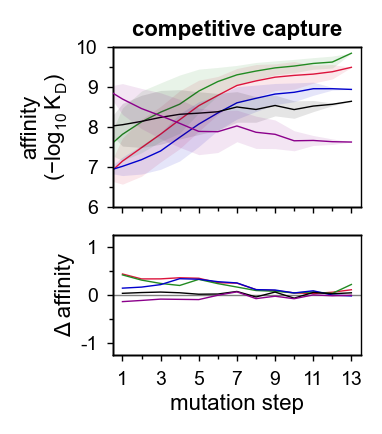

Plotting all phenotypes: 100%|██████████| 6/6 [00:02<00:00,  2.96it/s]


✓ Combined phenotype trajectory plotting complete


In [18]:
# PLOT ALL PHENOTYPE TRAJECTORIES - COMBINED VIEW

import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FixedFormatter, MultipleLocator

# Force Arial for all text elements
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.it'] = 'Arial:italic'
plt.rcParams['mathtext.bf'] = 'Arial:bold'

# ---------- STYLE KNOBS (match your final) ----------
TITLE_PAD_MAIN = 4
TITLE_PAD_DERIV = 3

HSPACE = 0.2

MAJOR_TICK_LEN = 2
MAJOR_TICK_WID = 0.5
MINOR_TICK_LEN = 1.5
MINOR_TICK_WID = 0.5

PLOT_LINEWIDTH = 0.5

# PSR color (use the same as your final pretty script)
PSR_COLOR = '#8b008b'

print("\nPlotting combined phenotype trajectories with derivatives...")

# Germline expression level for delta log expression conversion
GERMLINE_LOG_EXPRESSION = None  # Will be computed from germline sequence

for context in tqdm(antigen_contexts, desc="Plotting all phenotypes"):

    # Skip if no data
    if context not in best_path_mean_phenotypes:
        continue

    # Create figure with 2 rows: trajectories + derivatives
    # (UPDATED figsize/layout to match your final)
    fig, axes = plt.subplots(
        2, 1,
        figsize=(1.6, 2),
        height_ratios=[2, 1.5],
        sharex=True,
        gridspec_kw={'hspace': HSPACE}
    )
    ax_main = axes[0]
    ax_deriv = axes[1]

    # COLLECT ALL DATA
    all_data = {}
    all_means = {}
    all_stds = {}

    # Affinities
    for ag in antigens:
        data_key = f"{ag}_affinity"
        if data_key in best_paths_phenotypes.get(context, {}):
            aff_data = best_paths_phenotypes[context][data_key]
            all_data[data_key] = aff_data
            all_means[data_key] = np.mean(aff_data, axis=0)
            all_stds[data_key] = np.std(aff_data, axis=0)

    # Expression - convert to delta log expression from germline
    if "expression" in best_paths_phenotypes.get(context, {}):
        expr_data = best_paths_phenotypes[context]["expression"]

        # Get germline expression (first position, step 0)
        if GERMLINE_LOG_EXPRESSION is None:
            GERMLINE_LOG_EXPRESSION = np.mean(expr_data[:, 0])

        delta_log_expr_data = expr_data - GERMLINE_LOG_EXPRESSION

        all_data["expression"] = delta_log_expr_data
        all_means["expression"] = np.mean(delta_log_expr_data, axis=0)
        all_stds["expression"] = np.std(delta_log_expr_data, axis=0)

    # PSR
    if "psr" in best_paths_phenotypes.get(context, {}):
        psr_data = best_paths_phenotypes[context]["psr"]
        all_data["psr"] = psr_data
        all_means["psr"] = np.mean(psr_data, axis=0)
        all_stds["psr"] = np.std(psr_data, axis=0)

    # FIXED RANGES (as in your original delta-log script)
    aff_min, aff_max = 6, 10
    expr_min, expr_max = -0.3, 0.3
    psr_min, psr_max = 1.0, 2.5

    # CREATE THREE Y-AXES FOR MAIN PLOT
    ax_expr = ax_main.twinx()

    ax_psr = ax_main.twinx()
    ax_psr.spines['right'].set_position(('outward', 35))  # match your final style

    # Configuration for each phenotype
    # (keep labels if you want; legend is off anyway)
    phenotype_config = {
        'wuhan_affinity': {'color': colorWuhan, 'label': 'Wuhan affinity', 'linestyle': '-', 'axis': ax_main},
        'ba1_affinity': {'color': colorBA1, 'label': 'BA.1 affinity', 'linestyle': '-', 'axis': ax_main},
        'ba4_affinity': {'color': colorBA4, 'label': 'BA.4 affinity', 'linestyle': '-', 'axis': ax_main},
        'expression': {'color': "#000000", 'label': 'Expression', 'linestyle': '-', 'axis': ax_expr},
        'psr': {'color': PSR_COLOR, 'label': 'PSR (↑ worse)', 'linestyle': '-', 'axis': ax_psr}
    }

    # PLOT MAIN TRAJECTORIES (linewidth=0.5)
    for pheno_key, config in phenotype_config.items():
        if pheno_key not in all_means:
            continue

        mean = all_means[pheno_key]
        std = all_stds[pheno_key]
        ax = config['axis']

        ax.fill_between(
            range(L + 1),
            mean - std,
            mean + std,
            color=config['color'],
            alpha=0.1,
            linewidth=0,
            zorder=2
        )
        ax.plot(
            range(L + 1),
            mean,
            color=config['color'],
            linewidth=PLOT_LINEWIDTH,
            linestyle=config['linestyle'],
            zorder=3
        )

    # MAIN PLOT AXES FORMATTING (match your final)
    # Apply consistent tick styling to all main axes
    for a in [ax_main, ax_expr, ax_psr]:
        a.tick_params(which='major', length=MAJOR_TICK_LEN, width=MAJOR_TICK_WID, direction='out')
        a.tick_params(which='minor', length=MINOR_TICK_LEN, width=MINOR_TICK_WID, direction='out')

    # Left y-axis (affinity)
    ax_main.set_ylabel('affinity\n($-\log_{10} K_{\mathrm{D}}$)', fontsize=8, color='black', labelpad=0)
    ax_main.set_ylim(aff_min, aff_max)
    ax_main.yaxis.set_major_locator(FixedLocator([6, 7, 8, 9, 10]))
    ax_main.yaxis.set_minor_locator(FixedLocator([6.5, 7.5, 8.5, 9.5]))

    # Right y-axis (Δ expression; keep delta-log semantics)
    ax_expr.set_ylabel('Δ expression\nfrom germline\n(log$_{10}$ copy #$_{\\mathit{app}}$)', fontsize=8, color='black', labelpad=27.5, rotation=270)
    ax_expr.set_ylim(expr_min, expr_max)

    # Ticks for expression: keep it clean/minimal like your final script style
    ax_expr.yaxis.set_major_locator(FixedLocator([-0.2, 0.0, 0.2]))
    ax_expr.yaxis.set_major_formatter(FixedFormatter(['-0.2', '0', '0.2']))
    ax_expr.yaxis.set_minor_locator(FixedLocator([-0.1, 0.1]))
    ax_expr.spines['right'].set_color('black')

    # PSR axis: majors 1,2 ; minors 1.5,2.5 ; everything pink
    ax_psr.set_ylabel('polyspecificity\n($-\log_{10} \mathit{EC}_{\mathrm{50}}$)', fontsize=8, color=PSR_COLOR, labelpad=20, rotation=270)
    ax_psr.set_ylim(psr_min, psr_max)

    ax_psr.yaxis.set_major_locator(FixedLocator([1, 2]))
    ax_psr.yaxis.set_major_formatter(FixedFormatter(['1', '2']))
    ax_psr.yaxis.set_minor_locator(FixedLocator([1.5, 2.5]))

    ax_psr.tick_params(axis='y', labelcolor=PSR_COLOR)
    ax_psr.tick_params(axis='y', which='major', colors=PSR_COLOR)
    ax_psr.tick_params(axis='y', which='minor', colors=PSR_COLOR)
    ax_psr.spines['right'].set_color(PSR_COLOR)
    ax_psr.spines['right'].set_position(('outward', 50))

    

    # Title (not bold, match final)
    ax_main.set_title(TITLE_LABEL, fontsize=8, fontweight='bold', pad=TITLE_PAD_MAIN)

    # DERIVATIVES (Δ phenotype per step)
    ax_deriv_expr = ax_deriv.twinx()
    ax_deriv_psr = ax_deriv.twinx()
    ax_deriv_psr.spines['right'].set_position(('outward', 50))

    # Compute derivatives
    all_derivs = {}
    for pheno_key in all_means.keys():
        all_derivs[pheno_key] = np.diff(all_means[pheno_key])

    deriv_axis_map = {
        'wuhan_affinity': ax_deriv,
        'ba1_affinity': ax_deriv,
        'ba4_affinity': ax_deriv,
        'expression': ax_deriv_expr,
        'psr': ax_deriv_psr
    }

    x_deriv = np.arange(1, L + 1, 1)

    # Plot derivatives (linewidth=0.5)
    for pheno_key, config in phenotype_config.items():
        if pheno_key not in all_derivs:
            continue
        deriv = all_derivs[pheno_key]
        ax = deriv_axis_map[pheno_key]

        ax.plot(
            x_deriv,
            deriv,
            color=config['color'],
            linewidth=PLOT_LINEWIDTH,
            linestyle=config['linestyle'],
            marker='o',
            markersize=0,
            zorder=3
        )

    ax_deriv.axhline(0, color='black', linewidth=0.5, linestyle='-', alpha=0.5)

    # Apply consistent tick styling to derivative axes
    for a in [ax_deriv, ax_deriv_expr, ax_deriv_psr]:
        a.tick_params(which='major', length=MAJOR_TICK_LEN, width=MAJOR_TICK_WID, direction='out')
        a.tick_params(which='minor', length=MINOR_TICK_LEN, width=MINOR_TICK_WID, direction='out')

    # Left deriv axis (Δ affinity): labeled only -1,0,1 + minor ticks
    ax_deriv.set_ylabel('Δ affinity', fontsize=8, color='black', labelpad=2)
    ax_deriv.set_ylim(-1.25, 1.25)
    ax_deriv.yaxis.set_major_locator(FixedLocator([-1, 0, 1]))
    ax_deriv.yaxis.set_major_formatter(FixedFormatter(['-1', '0', '1']))
    ax_deriv.yaxis.set_minor_locator(MultipleLocator(0.5))

    # Expression deriv axis (ΔΔ expression): keep delta-log scale; clean ticks
    ax_deriv_expr.set_ylabel('ΔΔ expression', fontsize=8, color='black', labelpad=9.5, rotation=270)
    ax_deriv_expr.set_ylim(-0.3, 0.3)
    ax_deriv_expr.yaxis.set_major_locator(FixedLocator([-0.2, 0.0, 0.2]))
    ax_deriv_expr.yaxis.set_major_formatter(FixedFormatter(['-0.2', '0', '0.2']))
    ax_deriv_expr.yaxis.set_minor_locator(FixedLocator([-0.1, 0.1]))
    ax_deriv_expr.spines['right'].set_color('black')

    # PSR deriv axis: labeled only -1,0,1 + minor ticks; everything pink
    ax_deriv_psr.set_ylabel('Δ polyspecificity', fontsize=8, color=PSR_COLOR, labelpad=8, rotation=270)
    ax_deriv_psr.set_ylim(-1.0, 1.0)
    ax_deriv_psr.yaxis.set_major_locator(FixedLocator([-1, 0, 1]))
    ax_deriv_psr.yaxis.set_major_formatter(FixedFormatter(['-1', '0', '1']))
    ax_deriv_psr.yaxis.set_minor_locator(MultipleLocator(0.5))

    ax_deriv_psr.tick_params(axis='y', labelcolor=PSR_COLOR)
    ax_deriv_psr.tick_params(axis='y', which='major', colors=PSR_COLOR)
    ax_deriv_psr.tick_params(axis='y', which='minor', colors=PSR_COLOR)
    ax_deriv_psr.spines['right'].set_color(PSR_COLOR)

    # X AXIS (match final): major every other step, minor every step
    major_steps = np.arange(1, L + 1, 2)  # 1,3,5,...,13
    minor_steps = np.arange(1, L + 1, 1)  # all steps

    ax_deriv.set_xlabel('mutation step', fontsize=8, labelpad=2)
    ax_deriv.set_xlim(0.5, L + 0.5)

    ax_deriv.xaxis.set_major_locator(FixedLocator(major_steps))
    ax_deriv.xaxis.set_major_formatter(FixedFormatter([str(s) for s in major_steps]))
    ax_deriv.xaxis.set_minor_locator(FixedLocator(minor_steps))

    # Derivative plot title (match final casing/style)
    ax_deriv.set_title('', fontsize=0, style='italic', pad=TITLE_PAD_DERIV)

    # Save figure (match final)
    plt.tight_layout(pad=0)

    output_filename_f = f'{IMAGE_DIR}/combined_phenotypes_{antibody}_{context}_{fitness_model}_{selection_strength}_full.pdf'
    output_filename_l = f'{IMAGE_DIR}/combined_phenotypes_{antibody}_{context}_{fitness_model}_{selection_strength}_left.pdf'
    output_filename_r = f'{IMAGE_DIR}/combined_phenotypes_{antibody}_{context}_{fitness_model}_{selection_strength}_right.pdf'
    output_filename_e = f'{IMAGE_DIR}/combined_phenotypes_{antibody}_{context}_{fitness_model}_{selection_strength}_empty.pdf'

    plt.savefig(output_filename_f, bbox_inches='tight', transparent=True)
    plt.savefig(f'{IMAGE_DIR}/combined_phenotypes_{antibody}_{context}_{fitness_model}_{selection_strength}_full.png', dpi=2000, bbox_inches='tight', transparent=True)
    #plt.show()
    print(f"    ✓ Saved to: {output_filename_f}")
    ax_main.set_ylabel('')
    ax_main.yaxis.set_major_locator(FixedLocator([]))
    ax_main.yaxis.set_minor_locator(FixedLocator([]))
    ax_main.spines['left'].set_linewidth(0)
    ax_deriv.set_ylabel('')
    ax_deriv.yaxis.set_major_locator(FixedLocator([]))
    ax_deriv.yaxis.set_minor_locator(FixedLocator([]))
    ax_deriv.spines['left'].set_linewidth(0)
    plt.savefig(output_filename_r, bbox_inches='tight', transparent=True)
    plt.savefig(f'{IMAGE_DIR}/combined_phenotypes_{antibody}_{context}_{fitness_model}_{selection_strength}_right.png', dpi=2000, bbox_inches='tight', transparent=True)

    ax_expr.set_ylabel('')
    ax_expr.yaxis.set_major_locator(FixedLocator([]))
    ax_expr.yaxis.set_minor_locator(FixedLocator([]))
    ax_expr.spines['right'].set_linewidth(0)
    ax_psr.set_ylabel('')
    ax_psr.yaxis.set_major_locator(FixedLocator([]))
    ax_psr.yaxis.set_minor_locator(FixedLocator([]))
    ax_psr.spines['right'].set_linewidth(0)

    ax_deriv_expr.set_ylabel('')
    ax_deriv_expr.yaxis.set_major_locator(FixedLocator([]))
    ax_deriv_expr.yaxis.set_minor_locator(FixedLocator([]))
    ax_deriv_expr.spines['right'].set_linewidth(0)
    ax_deriv_psr.set_ylabel('')
    ax_deriv_psr.yaxis.set_major_locator(FixedLocator([]))
    ax_deriv_psr.yaxis.set_minor_locator(FixedLocator([]))
    ax_deriv_psr.spines['right'].set_linewidth(0)
    plt.savefig(output_filename_e, bbox_inches='tight', transparent=True)
    plt.savefig(f'{IMAGE_DIR}/combined_phenotypes_{antibody}_{context}_{fitness_model}_{selection_strength}_empty.png', dpi=2000, bbox_inches='tight', transparent=True)

    ax_main.set_ylabel('affinity\n($-\log_{10} K_{\mathrm{D}}$)', fontsize=8, color='black', labelpad=2)
    ax_main.yaxis.set_major_locator(FixedLocator([6, 7, 8, 9, 10]))
    ax_main.yaxis.set_minor_locator(FixedLocator([6.5, 7.5, 8.5, 9.5]))
    ax_main.spines['left'].set_linewidth(0.5)
    ax_deriv.set_ylabel('Δ affinity', fontsize=8, color='black', labelpad=2)
    ax_deriv.yaxis.set_major_locator(FixedLocator([-1, 0, 1]))
    ax_deriv.yaxis.set_minor_locator(FixedLocator([-0.5, 0.5]))
    ax_deriv.spines['left'].set_linewidth(0.5)
    plt.savefig(output_filename_l, bbox_inches='tight', transparent=True)
    plt.savefig(f'{IMAGE_DIR}/combined_phenotypes_{antibody}_{context}_{fitness_model}_{selection_strength}_left.png', dpi=2000, bbox_inches='tight', transparent=True)

    plt.show()

print("\n✓ Combined phenotype trajectory plotting complete")





## Least-likely paths for Supplemental Figure 4a (strong selection not shown in Tharp et al, 2026)

In [19]:
# FIND LEAST LIKELY EVOLUTIONARY PATHS
# (For moderate/weak selection only)

print("\nFinding LEAST likely evolutionary paths for each scenario...")

# Prepare fitness dictionaries

print("Preparing fitness dictionaries...")
fitnesses = {}

for ag in antigens + ['mixed']:
    # Calculate fitness using our unified function (handles all fitness models)
    fitness_array = calculate_fitness(ag, bootstrap_replicate=None)
    fitnesses[ag] = {i: fitness_array[i] for i in range(len(fitness_array))}

# Add mutation count column if not already present
if "nb_mutation" not in df.columns:
    df["nb_mutation"] = df.variant_int.apply(nb_mutation)

# Configuration

# uses NUM_WORST_PATHS from Cell 0

# Store results
worst_paths = {}

# Find paths for each scenario

# You can analyze all scenarios or just specific ones
# uses SCENARIOS_TO_ANALYZE from Cell 0

for ac in tqdm(SCENARIOS_TO_ANALYZE, desc="Finding worst paths"):
    
    print(f"\n  Scenario: {ac}")
    
    if selection_strength == 'strong':
        # STRONG SELECTION: All uphill paths are equally likely, so
        # "worst" is not meaningfully different from "best".
        # We sample an INDEPENDENT set of 1000 random uphill paths
        # (using a different seed offset) so that downstream plotting
        # and correlation cells have a second dataset to contrast.
        
        print(f"    Strong selection: Sampling {NUM_WORST_PATHS} independent random uphill paths...")
        print(f"    (Note: under strong selection all uphill paths are equally likely)")
        
        # Use a different seed so these are independent of best_paths
        _worst_rng_state = np.random.get_state()
        np.random.seed(99999)  # deterministic but different from best_paths sampling
        
        sampled_worst, _ = sample_multiple_paths_fast(
            antigen_contexts[ac],
            pmut_unnormed_mean,
            L,
            num_paths=NUM_WORST_PATHS
        )
        
        np.random.set_state(_worst_rng_state)  # restore
        
        if len(sampled_worst) == 0:
            print(f"    ✗ No uphill paths exist")
            worst_paths[ac] = np.empty((0, L + 1), dtype=int)
        else:
            worst_paths[ac] = sampled_worst
            print(f"    ✓ Sampled {len(sampled_worst):,} independent random uphill paths")
        continue
    
    # MODERATE/WEAK SELECTION: Use k-LONGEST paths (highest weight = lowest probability)
    
    print(f"    Moderate/weak selection: Finding {NUM_WORST_PATHS} LEAST likely paths...")
    
    # Create directed weighted graph
    G = nx.DiGraph()
    G.add_nodes_from(sequences_int)
    
    # Add weighted edges
    edges = []
    for s in sequences_int:
        nb_mut_s = nb_mutation(s)
        
        # Skip if we're at the somatic sequence (no outgoing edges)
        if nb_mut_s >= L:
            continue
        
        ag_at_step = antigen_contexts[ac][nb_mut_s]
        
        for t in reachable(s, L):
            # Get fixation probability from unnormalized matrix
            fix_prob = pmut_unnormed_mean[ag_at_step][s, t]
            
            # Edge weight = -log(probability)
            # Add small epsilon to avoid log(0)
            weight = -np.log(fix_prob + 1e-100)
            
            edges.append((s, t, weight))
    
    G.add_weighted_edges_from(edges)
    
    print(f"    Graph has {G.number_of_nodes():,} nodes and {G.number_of_edges():,} edges")
    
    # KEY CHANGE: Negate weights to find LONGEST paths
    
    # Create a new graph with negated weights
    G_negated = nx.DiGraph()
    G_negated.add_nodes_from(G.nodes())
    
    for u, v, data in G.edges(data=True):
        G_negated.add_edge(u, v, weight=-data['weight'])
    
    # Find k shortest paths on negated graph = k longest paths on original
    worst_paths[ac] = np.empty((NUM_WORST_PATHS, L + 1), dtype=int)
    
    try:
        i = 0
        for path in k_shortest_paths(G_negated, 0, 2**L - 1, NUM_WORST_PATHS, weight='weight'):
            worst_paths[ac][i] = path
            i += 1
            
        print(f"    ✓ Found {i} worst paths")
        
        # Calculate path probabilities (for reporting)
        path_probs = []
        for path_idx in range(min(5, i)):  # Show bottom 5
            path = worst_paths[ac][path_idx]
            log_prob = 0
            for step in range(L):
                s, t = path[step], path[step + 1]
                nb_mut_s = nb_mutation(s)
                ag_at_step = antigen_contexts[ac][nb_mut_s]
                fix_prob = pmut_unnormed_mean[ag_at_step][s, t]
                log_prob += np.log(fix_prob + 1e-100)
            path_probs.append(log_prob)
        
        print(f"    Bottom 5 path log-probabilities: {[f'{p:.2f}' for p in path_probs[:5]]}")
        
    except nx.NetworkXNoPath:
        print(f"    ⚠ No path exists from germline to somatic!")
        worst_paths[ac] = np.empty((0, L + 1), dtype=int)

# Save results

print("\nSaving worst path results...")

for ac in SCENARIOS_TO_ANALYZE:
    if len(worst_paths[ac]) > 0:
        # Convert paths to DataFrame for easy saving
        path_data = []
        for i, path in enumerate(worst_paths[ac]):
            # Convert each genotype in path to binary string
            path_strings = [format(g, f'0{L}b') for g in path]
            path_data.append({
                'path_rank': i + 1,
                'path': '->'.join(path_strings),
                **{f'step_{j}': path[j] for j in range(L + 1)}
            })
        
        path_df = pd.DataFrame(path_data)
        
        output_filename = f"{DATA_DIR}/{antibody}_worst_paths_{ac}_{fitness_model}_{selection_strength}.csv"
        
        path_df.to_csv(output_filename, index=False)
        print(f"  ✓ Saved {ac} worst paths to: {output_filename}")

print("\n✓ Worst path finding complete")


Finding LEAST likely evolutionary paths for each scenario...
Preparing fitness dictionaries...


Finding worst paths:   0%|          | 0/1 [00:00<?, ?it/s]


  Scenario: ba1_only
    Strong selection: Sampling 1000 independent random uphill paths...
    (Note: under strong selection all uphill paths are equally likely)
    Pre-computing viable sequences (backwards from somatic)...


      ✓ Found 1,813 viable sequences (out of 8,192)
    Sampling 1,000 paths...


Finding worst paths: 100%|██████████| 1/1 [00:00<00:00,  3.04it/s]

    ✓ Sampled 1,000 independent random uphill paths

Saving worst path results...
  ✓ Saved ba1_only worst paths to: competitive_antigen_capture/strong_norm_data/omi-32_worst_paths_ba1_only_competitive_capture_strong.csv

✓ Worst path finding complete


In [20]:
# EXTRACT PHENOTYPES ALONG WORST PATHS

print("\nExtracting phenotypes along WORST evolutionary paths...")

# Configuration
num_to_use = NUM_WORST_PATHS  # Number of worst paths to analyze

# Initialize storage dictionaries

# Storage for all paths
worst_paths_phenotypes = {}
worst_paths_phenotypes_err = {}

# Storage for mean/std across paths
worst_path_mean_phenotypes = {}
worst_path_std_phenotypes = {}

# Phenotypes to extract
phenotype_columns = {}
for ag in antigens:
    phenotype_columns[f"{ag}_affinity"] = f"{ag}_log10Kd"
    phenotype_columns[f"{ag}_affinity_err"] = f"{ag}_stelog10Kd"

# Also extract expression and PSR (useful for capture models)
phenotype_columns["expression"] = "expression_log10"
phenotype_columns["expression_err"] = "expression_stelog10"
phenotype_columns["psr"] = "psr_neglog10ec50"
phenotype_columns["psr_err"] = "psr_stelog10ec50"

# Extract phenotypes for each scenario

for ac in tqdm(antigen_contexts, desc="Scenarios"):
    
    # Skip if no paths were found
    if ac not in worst_paths or len(worst_paths[ac]) == 0:
        print(f"  ⚠ No worst paths found for {ac}, skipping")
        continue
    
    # Determine how many paths we actually have
    num_paths = min(num_to_use, len(worst_paths[ac]))
    
    # Initialize storage for this scenario
    worst_paths_phenotypes[ac] = {}
    worst_paths_phenotypes_err[ac] = {}
    worst_path_mean_phenotypes[ac] = {}
    worst_path_std_phenotypes[ac] = {}
    
    # Extract each phenotype
    for pheno_name, column_name in phenotype_columns.items():
        
        # Check if column exists in dataframe
        if column_name not in df.columns:
            print(f"  ⚠ Column {column_name} not found, skipping {pheno_name}")
            continue
        
        # Extract values along each path
        phenotype_array = np.empty((num_paths, L + 1), dtype=float)
        
        for i in range(num_paths):
            for step in range(L + 1):
                variant_int = worst_paths[ac][i, step]
                phenotype_array[i, step] = df.loc[variant_int, column_name]
        
        # Store individual paths
        if "_err" in pheno_name:
            worst_paths_phenotypes_err[ac][pheno_name.replace("_err", "")] = phenotype_array
        else:
            worst_paths_phenotypes[ac][pheno_name] = phenotype_array
            
            # Calculate mean and std across paths
            worst_path_mean_phenotypes[ac][pheno_name] = np.nanmean(phenotype_array, axis=0)
            worst_path_std_phenotypes[ac][pheno_name] = np.nanstd(phenotype_array, axis=0)

print("✓ Worst path phenotype extraction complete")

# Summary statistics

print("\nSummary of extracted data (WORST paths):")
for ac in antigen_contexts:
    if ac in worst_path_mean_phenotypes:
        print(f"\n  {ac}:")
        for ag in antigens:
            mean_traj = worst_path_mean_phenotypes[ac].get(f"{ag}_affinity")
            if mean_traj is not None:
                print(f"    {ag} affinity: {mean_traj[0]:.2f} (germline) → {mean_traj[-1]:.2f} (somatic)")
        
        # Show expression trajectory if using capture models
        if fitness_model in ['capture', 'competitive_capture']:
            expr_traj = worst_path_mean_phenotypes[ac].get("expression")
            if expr_traj is not None:
                print(f"    Expression: {expr_traj[0]:.2f} (germline) → {expr_traj[-1]:.2f} (somatic)")


Extracting phenotypes along WORST evolutionary paths...


Scenarios:   0%|          | 0/6 [00:00<?, ?it/s]

  ⚠ No worst paths found for optimal, skipping
  ⚠ No worst paths found for wuhan_only, skipping


Scenarios: 100%|██████████| 6/6 [00:00<00:00, 21.43it/s]

  ⚠ No worst paths found for ba4_only, skipping
  ⚠ No worst paths found for average_mixed, skipping
  ⚠ No worst paths found for random_median, skipping
✓ Worst path phenotype extraction complete

Summary of extracted data (WORST paths):

  ba1_only:
    wuhan affinity: 6.71 (germline) → 9.49 (somatic)
    ba1 affinity: 7.40 (germline) → 9.85 (somatic)
    ba4 affinity: 6.87 (germline) → 8.94 (somatic)
    Expression: 4.23 (germline) → 4.32 (somatic)


<>:135: SyntaxWarning: invalid escape sequence '\l'
<>:151: SyntaxWarning: invalid escape sequence '\l'
<>:306: SyntaxWarning: invalid escape sequence '\l'
<>:135: SyntaxWarning: invalid escape sequence '\l'
<>:151: SyntaxWarning: invalid escape sequence '\l'
<>:306: SyntaxWarning: invalid escape sequence '\l'
/var/folders/5c/ryv595916w771v24ng_5_tzw0000gn/T/ipykernel_5634/1484277632.py:135: SyntaxWarning: invalid escape sequence '\l'
  ax_main.set_ylabel('affinity\n($-\log_{10} K_{\mathrm{D}}$)', fontsize=8, color='black', labelpad=0)
/var/folders/5c/ryv595916w771v24ng_5_tzw0000gn/T/ipykernel_5634/1484277632.py:151: SyntaxWarning: invalid escape sequence '\l'
  ax_psr.set_ylabel('polyspecificity\n($-\log_{10} \mathit{EC}_{\mathrm{50}}$)', fontsize=8, color=PSR_COLOR, labelpad=20, rotation=270)
/var/folders/5c/ryv595916w771v24ng_5_tzw0000gn/T/ipykernel_5634/1484277632.py:306: SyntaxWarning: invalid escape sequence '\l'
  ax_main.set_ylabel('affinity\n($-\log_{10} K_{\mathrm{D}}$)', fon


Plotting combined phenotype trajectories with derivatives (WORST PATHS; delta-log expr)...


Plotting all phenotypes:   0%|          | 0/6 [00:00<?, ?it/s]/var/folders/5c/ryv595916w771v24ng_5_tzw0000gn/T/ipykernel_5634/1484277632.py:247: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=0)


    ✓ Saved to: competitive_antigen_capture/strong_norm_images/worst_combined_phenotypes_omi-32_ba1_only_competitive_capture_strong_full.pdf


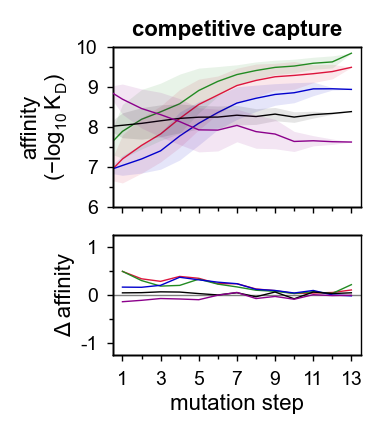

Plotting all phenotypes: 100%|██████████| 6/6 [00:02<00:00,  2.96it/s]


✓ Worst path combined phenotype trajectory plotting complete


In [21]:
# PLOT ALL PHENOTYPE TRAJECTORIES - WORST PATHS - COMBINED VIEW

import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FixedFormatter, MultipleLocator

# Force Arial for all text elements
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.it'] = 'Arial:italic'
plt.rcParams['mathtext.bf'] = 'Arial:bold'

# ---------- STYLE KNOBS (match your final) ----------
TITLE_PAD_MAIN = 4
TITLE_PAD_DERIV = 3

HSPACE = 0.2

MAJOR_TICK_LEN = 2
MAJOR_TICK_WID = 0.5
MINOR_TICK_LEN = 1.5
MINOR_TICK_WID = 0.5

PLOT_LINEWIDTH = 0.5

PSR_COLOR = '#8b008b'

print("\nPlotting combined phenotype trajectories with derivatives (WORST PATHS; delta-log expr)...")

GERMLINE_LOG_EXPRESSION = None  # computed from germline sequence

for context in tqdm(antigen_contexts, desc="Plotting all phenotypes"):

    if context not in worst_path_mean_phenotypes:
        continue

    # Figure layout (MATCH template)
    fig, axes = plt.subplots(
        2, 1,
        figsize=(1.6, 2),
        height_ratios=[2, 1.5],
        sharex=True,
        gridspec_kw={'hspace': HSPACE}
    )
    ax_main = axes[0]
    ax_deriv = axes[1]

    # COLLECT ALL DATA
    all_data = {}
    all_means = {}
    all_stds = {}

    # Affinities
    for ag in antigens:
        data_key = f"{ag}_affinity"
        if data_key in worst_paths_phenotypes.get(context, {}):
            aff_data = worst_paths_phenotypes[context][data_key]
            all_data[data_key] = aff_data
            all_means[data_key] = np.mean(aff_data, axis=0)
            all_stds[data_key] = np.std(aff_data, axis=0)

    # Expression (delta log expression from germline)
    if "expression" in worst_paths_phenotypes.get(context, {}):
        expr_data = worst_paths_phenotypes[context]["expression"]

        if GERMLINE_LOG_EXPRESSION is None:
            GERMLINE_LOG_EXPRESSION = np.mean(expr_data[:, 0])

        delta_log_expr_data = expr_data - GERMLINE_LOG_EXPRESSION

        all_data["expression"] = delta_log_expr_data
        all_means["expression"] = np.mean(delta_log_expr_data, axis=0)
        all_stds["expression"] = np.std(delta_log_expr_data, axis=0)

    # PSR
    if "psr" in worst_paths_phenotypes.get(context, {}):
        psr_data = worst_paths_phenotypes[context]["psr"]
        all_data["psr"] = psr_data
        all_means["psr"] = np.mean(psr_data, axis=0)
        all_stds["psr"] = np.std(psr_data, axis=0)

    # FIXED RANGES (keep your worst delta-log semantics)
    aff_min, aff_max = 6, 10
    expr_min, expr_max = -0.5, 0.5
    psr_min, psr_max = 1.0, 2.5

    # THREE Y-AXES (main)
    ax_expr = ax_main.twinx()

    ax_psr = ax_main.twinx()
    ax_psr.spines['right'].set_position(('outward', 35))  # base offset like template (we then push to 50 below)

    phenotype_config = {
        'wuhan_affinity': {'color': colorWuhan, 'label': 'Wuhan affinity', 'linestyle': '-', 'axis': ax_main},
        'ba1_affinity': {'color': colorBA1, 'label': 'BA.1 affinity', 'linestyle': '-', 'axis': ax_main},
        'ba4_affinity': {'color': colorBA4, 'label': 'BA.4 affinity', 'linestyle': '-', 'axis': ax_main},
        'expression':    {'color': "#000000",  'label': 'Expression',     'linestyle': '-', 'axis': ax_expr},
        'psr':           {'color': PSR_COLOR,  'label': 'PSR (↑ worse)',   'linestyle': '-', 'axis': ax_psr}
    }

    # PLOT MAIN (linewidth=0.5)
    for pheno_key, config in phenotype_config.items():
        if pheno_key not in all_means:
            continue

        mean = all_means[pheno_key]
        std = all_stds[pheno_key]
        ax = config['axis']

        ax.fill_between(
            range(L + 1),
            mean - std,
            mean + std,
            color=config['color'],
            alpha=0.1,
            linewidth=0,
            zorder=2
        )
        ax.plot(
            range(L + 1),
            mean,
            color=config['color'],
            linewidth=PLOT_LINEWIDTH,
            linestyle=config['linestyle'],
            zorder=3
        )

    # MAIN AXIS FORMATTING (MATCH template)
    for a in [ax_main, ax_expr, ax_psr]:
        a.tick_params(which='major', length=MAJOR_TICK_LEN, width=MAJOR_TICK_WID, direction='out')
        a.tick_params(which='minor', length=MINOR_TICK_LEN, width=MINOR_TICK_WID, direction='out')

    # Affinity (left)
    ax_main.set_ylabel('affinity\n($-\log_{10} K_{\mathrm{D}}$)', fontsize=8, color='black', labelpad=0)
    ax_main.set_ylim(aff_min, aff_max)
    ax_main.yaxis.set_major_locator(FixedLocator([6, 7, 8, 9, 10]))
    ax_main.yaxis.set_minor_locator(FixedLocator([6.5, 7.5, 8.5, 9.5]))
    ax_main.yaxis.set_minor_locator(FixedLocator([6.5, 7.5, 8.5, 9.5]))

    # Δ expression (right #1)
    ax_expr.set_ylabel('Δ expression\nfrom germline\n(log$_{10}$ copy #$_{\\mathit{app}}$)', fontsize=8, color='black', labelpad=27.5, rotation=270)
    ax_expr.set_ylim(-0.5, 0.5)

    ax_expr.yaxis.set_major_locator(FixedLocator([-0.4, -0.2, 0.0, 0.2, 0.4]))
    ax_expr.yaxis.set_major_formatter(FixedFormatter(['-0.4', '-0.2', '0', '0.2', '0.4']))
    ax_expr.yaxis.set_minor_locator(FixedLocator([-0.3, -0.1, 0.1, 0.3]))
    ax_expr.spines['right'].set_color('black')

    # PSR (right #2, pink, offset 50)
    ax_psr.set_ylabel('polyspecificity\n($-\log_{10} \mathit{EC}_{\mathrm{50}}$)', fontsize=8, color=PSR_COLOR, labelpad=20, rotation=270)
    ax_psr.set_ylim(psr_min, psr_max)

    ax_psr.yaxis.set_major_locator(FixedLocator([1, 2]))
    ax_psr.yaxis.set_major_formatter(FixedFormatter(['1', '2']))
    ax_psr.yaxis.set_minor_locator(FixedLocator([1.5, 2.5]))

    ax_psr.tick_params(axis='y', labelcolor=PSR_COLOR)
    ax_psr.tick_params(axis='y', which='major', colors=PSR_COLOR)
    ax_psr.tick_params(axis='y', which='minor', colors=PSR_COLOR)
    ax_psr.spines['right'].set_color(PSR_COLOR)
    ax_psr.spines['right'].set_position(('outward', 50))

    # Title (not bold)
    ax_main.set_title(TITLE_LABEL, fontsize=8, fontweight='bold', pad=TITLE_PAD_MAIN)

    # DERIVATIVES
    ax_deriv_expr = ax_deriv.twinx()
    ax_deriv_psr = ax_deriv.twinx()
    ax_deriv_psr.spines['right'].set_position(('outward', 50))

    all_derivs = {k: np.diff(v) for k, v in all_means.items()}

    deriv_axis_map = {
        'wuhan_affinity': ax_deriv,
        'ba1_affinity': ax_deriv,
        'ba4_affinity': ax_deriv,
        'expression': ax_deriv_expr,
        'psr': ax_deriv_psr
    }

    x_deriv = np.arange(1, L + 1, 1)

    for pheno_key, config in phenotype_config.items():
        if pheno_key not in all_derivs:
            continue

        ax = deriv_axis_map[pheno_key]
        ax.plot(
            x_deriv,
            all_derivs[pheno_key],
            color=config['color'],
            linewidth=PLOT_LINEWIDTH,
            linestyle=config['linestyle'],
            marker='o',
            markersize=0,
            zorder=3
        )

    ax_deriv.axhline(0, color='black', linewidth=0.5, linestyle='-', alpha=0.5)

    for a in [ax_deriv, ax_deriv_expr, ax_deriv_psr]:
        a.tick_params(which='major', length=MAJOR_TICK_LEN, width=MAJOR_TICK_WID, direction='out')
        a.tick_params(which='minor', length=MINOR_TICK_LEN, width=MINOR_TICK_WID, direction='out')

    # Δ affinity (left)
    ax_deriv.set_ylabel('Δ affinity', fontsize=8, color='black', labelpad=2)
    ax_deriv.set_ylim(-1.25, 1.25)
    ax_deriv.yaxis.set_major_locator(FixedLocator([-1, 0, 1]))
    ax_deriv.yaxis.set_major_formatter(FixedFormatter(['-1', '0', '1']))
    ax_deriv.yaxis.set_minor_locator(MultipleLocator(0.5))

    # ΔΔ expression (right #1)
    ax_deriv_expr.set_ylabel('ΔΔ expression', fontsize=8, color='black', labelpad=9.5, rotation=270)
    ax_deriv_expr.set_ylim(-0.3, 0.3)
    ax_deriv_expr.yaxis.set_major_locator(FixedLocator([-0.2, 0.0, 0.2]))
    ax_deriv_expr.yaxis.set_major_formatter(FixedFormatter(['-0.2', '0', '0.2']))
    ax_deriv_expr.yaxis.set_minor_locator(FixedLocator([-0.3,-0.1, 0.1, 0.3]))
    ax_deriv_expr.spines['right'].set_color('black')

    # Δ PSR (right #2, pink)
    ax_deriv_psr.set_ylabel('Δ polyspecificity', fontsize=8, color=PSR_COLOR, labelpad=8, rotation=270)
    ax_deriv_psr.set_ylim(-1.0, 1.0)
    ax_deriv_psr.yaxis.set_major_locator(FixedLocator([-1, 0, 1]))
    ax_deriv_psr.yaxis.set_major_formatter(FixedFormatter(['-1', '0', '1']))
    ax_deriv_psr.yaxis.set_minor_locator(MultipleLocator(0.5))

    ax_deriv_psr.tick_params(axis='y', labelcolor=PSR_COLOR)
    ax_deriv_psr.tick_params(axis='y', which='major', colors=PSR_COLOR)
    ax_deriv_psr.tick_params(axis='y', which='minor', colors=PSR_COLOR)
    ax_deriv_psr.spines['right'].set_color(PSR_COLOR)

    # X AXIS (match template): major every other step, minor every step
    major_steps = np.arange(1, L + 1, 2)
    minor_steps = np.arange(1, L + 1, 1)

    ax_deriv.set_xlabel('mutation step', fontsize=8, labelpad=2)
    ax_deriv.set_xlim(0.5, L + 0.5)
    ax_deriv.xaxis.set_major_locator(FixedLocator(major_steps))
    ax_deriv.xaxis.set_major_formatter(FixedFormatter([str(s) for s in major_steps]))
    ax_deriv.xaxis.set_minor_locator(FixedLocator(minor_steps))

    # No derivative title (match template)
    ax_deriv.set_title('', fontsize=0, style='italic', pad=TITLE_PAD_DERIV)

    # SAVE (match template multi-save)
    plt.tight_layout(pad=0)

    output_filename_f = f'{IMAGE_DIR}/worst_combined_phenotypes_{antibody}_{context}_{fitness_model}_{selection_strength}_full.pdf'
    output_filename_l = f'{IMAGE_DIR}/worst_combined_phenotypes_{antibody}_{context}_{fitness_model}_{selection_strength}_left.pdf'
    output_filename_r = f'{IMAGE_DIR}/worst_combined_phenotypes_{antibody}_{context}_{fitness_model}_{selection_strength}_right.pdf'
    output_filename_e = f'{IMAGE_DIR}/worst_combined_phenotypes_{antibody}_{context}_{fitness_model}_{selection_strength}_empty.pdf'

    plt.savefig(output_filename_f, bbox_inches='tight', transparent=True)
    plt.savefig(
        f'{IMAGE_DIR}/worst_combined_phenotypes_{antibody}_{context}_{fitness_model}_{selection_strength}_full.png',
        dpi=2000, bbox_inches='tight', transparent=True
    )
    print(f"    ✓ Saved to: {output_filename_f}")
    #plt.show()
    # ---------- RIGHT-ONLY ----------
    ax_main.set_ylabel('')
    ax_main.yaxis.set_major_locator(FixedLocator([]))
    ax_main.yaxis.set_minor_locator(FixedLocator([]))
    ax_main.spines['left'].set_linewidth(0)

    ax_deriv.set_ylabel('')
    ax_deriv.yaxis.set_major_locator(FixedLocator([]))
    ax_deriv.yaxis.set_minor_locator(FixedLocator([]))
    ax_deriv.spines['left'].set_linewidth(0)

    plt.savefig(output_filename_r, bbox_inches='tight', transparent=True)
    plt.savefig(
        f'{IMAGE_DIR}/worst_combined_phenotypes_{antibody}_{context}_{fitness_model}_{selection_strength}_right.png',
        dpi=2000, bbox_inches='tight', transparent=True
    )

    # ---------- EMPTY ----------
    ax_expr.set_ylabel('')
    ax_expr.yaxis.set_major_locator(FixedLocator([]))
    ax_expr.yaxis.set_minor_locator(FixedLocator([]))
    ax_expr.spines['right'].set_linewidth(0)

    ax_psr.set_ylabel('')
    ax_psr.yaxis.set_major_locator(FixedLocator([]))
    ax_psr.yaxis.set_minor_locator(FixedLocator([]))
    ax_psr.spines['right'].set_linewidth(0)

    ax_deriv_expr.set_ylabel('')
    ax_deriv_expr.yaxis.set_major_locator(FixedLocator([]))
    ax_deriv_expr.yaxis.set_minor_locator(FixedLocator([]))
    ax_deriv_expr.spines['right'].set_linewidth(0)

    ax_deriv_psr.set_ylabel('')
    ax_deriv_psr.yaxis.set_major_locator(FixedLocator([]))
    ax_deriv_psr.yaxis.set_minor_locator(FixedLocator([]))
    ax_deriv_psr.spines['right'].set_linewidth(0)

    plt.savefig(output_filename_e, bbox_inches='tight', transparent=True)
    plt.savefig(
        f'{IMAGE_DIR}/worst_combined_phenotypes_{antibody}_{context}_{fitness_model}_{selection_strength}_empty.png',
        dpi=2000, bbox_inches='tight', transparent=True
    )

    # ---------- LEFT-ONLY ----------
    ax_main.set_ylabel('affinity\n($-\log_{10} K_{\mathrm{D}}$)', fontsize=8, color='black', labelpad=2)
    ax_main.yaxis.set_major_locator(FixedLocator([6, 7, 8, 9, 10]))
    ax_main.yaxis.set_minor_locator(FixedLocator([6.5, 7.5, 8.5, 9.5]))
    ax_main.spines['left'].set_linewidth(0.5)

    ax_deriv.set_ylabel('Δ affinity', fontsize=8, color='black', labelpad=2)
    ax_deriv.yaxis.set_major_locator(FixedLocator([-1, 0, 1]))
    ax_deriv.yaxis.set_minor_locator(FixedLocator([-0.5, 0.5]))
    ax_deriv.spines['left'].set_linewidth(0.5)

    plt.savefig(output_filename_l, bbox_inches='tight', transparent=True)
    plt.savefig(
        f'{IMAGE_DIR}/worst_combined_phenotypes_{antibody}_{context}_{fitness_model}_{selection_strength}_left.png',
        dpi=2000, bbox_inches='tight', transparent=True
    )

    plt.show()

print("\n✓ Worst path combined phenotype trajectory plotting complete")


## Correlation analysis for most-likely and least-likely paths for Supplemental Figure 4b-d (strong selection not shown in Tharp et al, 2026)

<>:127: SyntaxWarning: invalid escape sequence '\l'
<>:165: SyntaxWarning: invalid escape sequence '\l'
<>:166: SyntaxWarning: invalid escape sequence '\l'
<>:204: SyntaxWarning: invalid escape sequence '\l'
<>:242: SyntaxWarning: invalid escape sequence '\l'
<>:243: SyntaxWarning: invalid escape sequence '\l'
<>:127: SyntaxWarning: invalid escape sequence '\l'
<>:165: SyntaxWarning: invalid escape sequence '\l'
<>:166: SyntaxWarning: invalid escape sequence '\l'
<>:204: SyntaxWarning: invalid escape sequence '\l'
<>:242: SyntaxWarning: invalid escape sequence '\l'
<>:243: SyntaxWarning: invalid escape sequence '\l'
/var/folders/5c/ryv595916w771v24ng_5_tzw0000gn/T/ipykernel_5634/752573739.py:127: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('Δ BA.1 affinity\n($-\log_{10} K_{\mathrm{D}}$)', fontsize=7, labelpad=2)
/var/folders/5c/ryv595916w771v24ng_5_tzw0000gn/T/ipykernel_5634/752573739.py:165: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel('Δ BA.1 affinity\n


Generating step-wise correlation plots for ba1_only scenario...

  Data points:
    Best paths:  1000 paths × 13 steps = 13000 points
    Worst paths: 1000 paths × 13 steps = 13000 points

  Correlations (step-by-step):
    Best paths:  Δ BA1 vs Δ Expr: r = -0.185 (p = 1.10e-100)
    Best paths:  Δ BA1 vs Δ PSR:  r = -0.308 (p = 1.54e-283)
    Worst paths: Δ BA1 vs Δ Expr: r = -0.138 (p = 4.65e-56)
    Worst paths: Δ BA1 vs Δ PSR:  r = -0.294 (p = 4.47e-258)

  ✓ Saved to: competitive_antigen_capture/strong_norm_images/correlation_stepwise_omi-32_ba1_only_competitive_capture_strong.png

  ✓ Saved to: competitive_antigen_capture/strong_norm_images/correlation_stepwise_omi-32_ba1_only_competitive_capture_strong.pdf


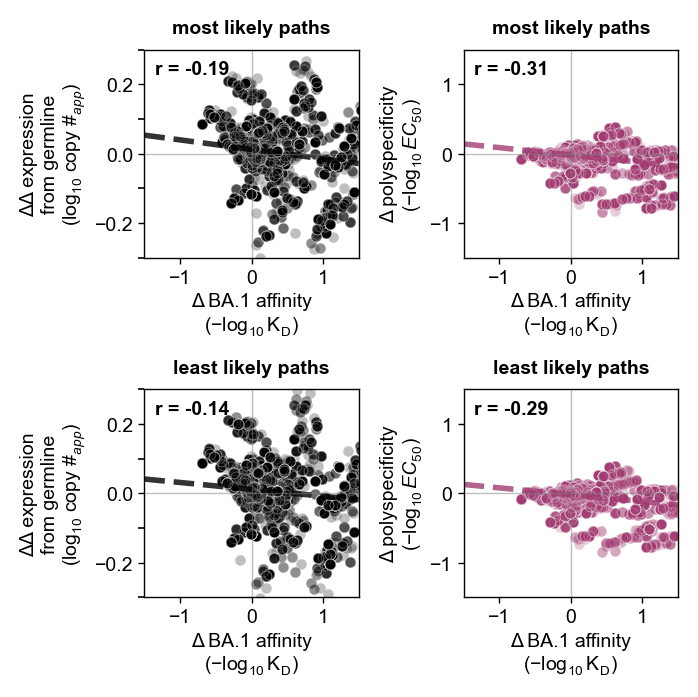


STEP-WISE CORRELATION SUMMARY

BEST PATHS (most likely):
  Δ BA1 vs Δ Expression: r = -0.185
    → Affinity gains tend to come WITH expression losses (trade-off)
  Δ BA1 vs Δ PSR: r = -0.308
    → Affinity gains tend to come WITH PSR decreases (favorable)

WORST PATHS (least likely):
  Δ BA1 vs Δ Expression: r = -0.138
    → Affinity gains tend to come WITH expression losses (trade-off)
  Δ BA1 vs Δ PSR: r = -0.294
    → Affinity gains tend to come WITH PSR decreases (favorable)


✓ Step-wise correlation plotting complete


In [22]:
# CORRELATION PLOTS: Δ BA1 affinity vs Δ Expression and Δ PSR
# For EACH STEP in best and worst paths (13 steps × 25 paths = 325 points)

import matplotlib.pyplot as plt
import matplotlib as mpl

# Force Arial for all text elements
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.it'] = 'Arial:italic'
plt.rcParams['mathtext.bf'] = 'Arial:bold'

print("\nGenerating step-wise correlation plots for ba1_only scenario...")

context = 'ba1_only'

# Germline expression level for delta log expression conversion
GERMLINE_LOG_EXPRESSION = None  # Will be computed from germline sequence

# Check if we have data
if context not in best_paths_phenotypes:
    print(f"  ⚠ No best path data for {context}")
elif context not in worst_paths_phenotypes:
    print(f"  ⚠ No worst path data for {context}")
else:
    # EXTRACT DELTA VALUES FOR EACH STEP IN EACH PATH
    
    # Best paths - compute step-by-step deltas
    best_ba1_data = best_paths_phenotypes[context]['ba1_affinity']  # Shape: (25, 14)
    best_expr_data = best_paths_phenotypes[context]['expression']    # Shape: (25, 14)
    best_psr_data = best_paths_phenotypes[context]['psr']            # Shape: (25, 14)
    
    # Get germline expression (first position, step 0)
    if GERMLINE_LOG_EXPRESSION is None:
        GERMLINE_LOG_EXPRESSION = np.mean(best_expr_data[:, 0])
    
    # Convert to delta log expression from germline
    best_delta_log_expr = best_expr_data - GERMLINE_LOG_EXPRESSION
    
    # Compute deltas between consecutive steps (shape: 25 paths × 13 steps)
    best_delta_ba1_steps = np.diff(best_ba1_data, axis=1)   # Shape: (25, 13)
    best_delta_expr_steps = np.diff(best_delta_log_expr, axis=1)  # Shape: (25, 13) - delta delta log expr
    best_delta_psr_steps = np.diff(best_psr_data, axis=1)    # Shape: (25, 13)
    
    # Flatten to get all step deltas (325 points)
    best_delta_ba1_flat = best_delta_ba1_steps.flatten()
    best_delta_expr_flat = best_delta_expr_steps.flatten()
    best_delta_psr_flat = best_delta_psr_steps.flatten()
    
    # Worst paths - compute step-by-step deltas
    worst_ba1_data = worst_paths_phenotypes[context]['ba1_affinity']
    worst_expr_data = worst_paths_phenotypes[context]['expression']
    worst_psr_data = worst_paths_phenotypes[context]['psr']
    
    # Convert to delta log expression from germline
    worst_delta_log_expr = worst_expr_data - GERMLINE_LOG_EXPRESSION
    
    worst_delta_ba1_steps = np.diff(worst_ba1_data, axis=1)
    worst_delta_expr_steps = np.diff(worst_delta_log_expr, axis=1)  # Delta delta log expr
    worst_delta_psr_steps = np.diff(worst_psr_data, axis=1)
    
    worst_delta_ba1_flat = worst_delta_ba1_steps.flatten()
    worst_delta_expr_flat = worst_delta_expr_steps.flatten()
    worst_delta_psr_flat = worst_delta_psr_steps.flatten()
    
    n_points_best = len(best_delta_ba1_flat)
    n_points_worst = len(worst_delta_ba1_flat)
    
    print(f"\n  Data points:")
    print(f"    Best paths:  {best_delta_ba1_steps.shape[0]} paths × {best_delta_ba1_steps.shape[1]} steps = {n_points_best} points")
    print(f"    Worst paths: {worst_delta_ba1_steps.shape[0]} paths × {worst_delta_ba1_steps.shape[1]} steps = {n_points_worst} points")
    
    # COMPUTE CORRELATIONS
    
    from scipy.stats import pearsonr
    
    # Best paths correlations
    r_best_expr, p_best_expr = pearsonr(best_delta_ba1_flat, best_delta_expr_flat)
    r_best_psr, p_best_psr = pearsonr(best_delta_ba1_flat, best_delta_psr_flat)
    
    # Worst paths correlations
    r_worst_expr, p_worst_expr = pearsonr(worst_delta_ba1_flat, worst_delta_expr_flat)
    r_worst_psr, p_worst_psr = pearsonr(worst_delta_ba1_flat, worst_delta_psr_flat)
    
    print(f"\n  Correlations (step-by-step):")
    print(f"    Best paths:  Δ BA1 vs Δ Expr: r = {r_best_expr:+.3f} (p = {p_best_expr:.2e})")
    print(f"    Best paths:  Δ BA1 vs Δ PSR:  r = {r_best_psr:+.3f} (p = {p_best_psr:.2e})")
    print(f"    Worst paths: Δ BA1 vs Δ Expr: r = {r_worst_expr:+.3f} (p = {p_worst_expr:.2e})")
    print(f"    Worst paths: Δ BA1 vs Δ PSR:  r = {r_worst_psr:+.3f} (p = {p_worst_psr:.2e})")
    
    # CREATE FIGURE: 2x2 grid
    
    fig, axes = plt.subplots(2, 2, figsize=(3.5,3.5))
    
    # Colors
    expr_color = "#000000"
    psr_color = '#A23B72'
    
    # PLOT 1: Best paths - Δ BA1 vs Δ Expression (per step)
    
    ax = axes[0, 0]
    
    ax.scatter(best_delta_ba1_flat, best_delta_expr_flat, 
               c=expr_color, alpha=0.25, s=15, edgecolor='white', linewidth=0.3)
    
    # Regression line
    z = np.polyfit(best_delta_ba1_flat, best_delta_expr_flat, 1)
    p = np.poly1d(z)
    x_line = np.linspace(-1.5, 1.5, 100)
    ax.plot(x_line, p(x_line), color=expr_color, linestyle='--', linewidth=2, alpha=0.8)
    
    # Fixed axes
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-0.3, 0.3)
    ax.set_xticks([-1, 0, 1])
    ax.set_yticks([-0.2, 0, 0.2])
    ax.set_yticks([-0.3, -0.1, 0.1, 0.3], minor=True)
    ax.tick_params(axis='both', labelsize=7, pad=2)
    
    # Reference lines
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='-', alpha=0.5)
    ax.axvline(0, color='gray', linewidth=0.5, linestyle='-', alpha=0.5)
    
    # Labels
    ax.set_xlabel('Δ BA.1 affinity\n($-\log_{10} K_{\mathrm{D}}$)', fontsize=7, labelpad=2)
    ax.set_ylabel('ΔΔ expression\nfrom germline\n(log$_{10}$ copy #$_{\\mathit{app}}$)', fontsize=7, labelpad=2)
    ax.set_title(f'most likely paths', 
                 fontsize=7, fontweight='bold')
    
    # Add r value inside panel
    ax.text(0.05, 0.95, f'r = {r_best_expr:.2f}',
            transform=ax.transAxes,
            fontsize=7,
            va='top',
            ha='left',
            fontweight='bold')
    
    # PLOT 2: Best paths - Δ BA1 vs Δ PSR (per step)
    
    ax = axes[0, 1]
    
    ax.scatter(best_delta_ba1_flat, best_delta_psr_flat, 
               c=psr_color, alpha=0.25, s=15, edgecolor='white', linewidth=0.3)
    
    # Regression line
    z = np.polyfit(best_delta_ba1_flat, best_delta_psr_flat, 1)
    p = np.poly1d(z)
    x_line = np.linspace(-1.5, 1.5, 100)
    ax.plot(x_line, p(x_line), color=psr_color, linestyle='--', linewidth=2, alpha=0.8)
    
    # Fixed axes
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_xticks([-1, 0, 1])
    ax.set_yticks([-1, 0, 1])
    ax.tick_params(axis='both', labelsize=7, pad=2)
    
    # Reference lines
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='-', alpha=0.5)
    ax.axvline(0, color='gray', linewidth=0.5, linestyle='-', alpha=0.5)
    
    # Labels
    ax.set_xlabel('Δ BA.1 affinity\n($-\log_{10} K_{\mathrm{D}}$)', fontsize=7, labelpad=2)
    ax.set_ylabel('Δ polyspecificity\n($-\log_{10} \mathit{EC}_{\mathrm{50}}$)', fontsize=7, labelpad=2)
    ax.set_title(f'most likely paths', 
                 fontsize=7, fontweight='bold')
    
    # Add r value inside panel
    ax.text(0.05, 0.95, f'r = {r_best_psr:.2f}',
            transform=ax.transAxes,
            fontsize=7,
            va='top',
            ha='left',
            fontweight='bold')
    
    # PLOT 3: Worst paths - Δ BA1 vs Δ Expression (per step)
    
    ax = axes[1, 0]
    
    ax.scatter(worst_delta_ba1_flat, worst_delta_expr_flat, 
               c=expr_color, alpha=0.25, s=15, edgecolor='white', linewidth=0.3)
    
    # Regression line
    z = np.polyfit(worst_delta_ba1_flat, worst_delta_expr_flat, 1)
    p = np.poly1d(z)
    x_line = np.linspace(-1.5, 1.5, 100)
    ax.plot(x_line, p(x_line), color=expr_color, linestyle='--', linewidth=2, alpha=0.8)
    
    # Fixed axes
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-0.3, 0.3)
    ax.set_xticks([-1, 0, 1])
    ax.set_yticks([-0.2, 0, 0.2])
    ax.set_yticks([-0.3, -0.1, 0.1, 0.3], minor=True)
    ax.tick_params(axis='both', labelsize=7, pad=2)
    
    # Reference lines
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='-', alpha=0.5)
    ax.axvline(0, color='gray', linewidth=0.5, linestyle='-', alpha=0.5)
    
    # Labels
    ax.set_xlabel('Δ BA.1 affinity\n($-\log_{10} K_{\mathrm{D}}$)', fontsize=7, labelpad=2)
    ax.set_ylabel('ΔΔ expression\nfrom germline\n(log$_{10}$ copy #$_{\\mathit{app}}$)', fontsize=7, labelpad=2)
    ax.set_title(f'least likely paths', 
                 fontsize=7, fontweight='bold')
    
    # Add r value inside panel
    ax.text(0.05, 0.95, f'r = {r_worst_expr:.2f}',
            transform=ax.transAxes,
            fontsize=7,
            va='top',
            ha='left',
            fontweight='bold')
    
    # PLOT 4: Worst paths - Δ BA1 vs Δ PSR (per step)
    
    ax = axes[1, 1]
    
    ax.scatter(worst_delta_ba1_flat, worst_delta_psr_flat, 
               c=psr_color, alpha=0.25, s=15, edgecolor='white', linewidth=0.3)
    
    # Regression line
    z = np.polyfit(worst_delta_ba1_flat, worst_delta_psr_flat, 1)
    p = np.poly1d(z)
    x_line = np.linspace(-1.5, 1.5, 100)
    ax.plot(x_line, p(x_line), color=psr_color, linestyle='--', linewidth=2, alpha=0.8)
    
    # Fixed axes
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_xticks([-1, 0, 1])
    ax.set_yticks([-1, 0, 1])
    ax.tick_params(axis='both', labelsize=7, pad=2)
    
    # Reference lines
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='-', alpha=0.5)
    ax.axvline(0, color='gray', linewidth=0.5, linestyle='-', alpha=0.5)
    
    # Labels
    ax.set_xlabel('Δ BA.1 affinity\n($-\log_{10} K_{\mathrm{D}}$)', fontsize=7, labelpad=2)
    ax.set_ylabel('Δ polyspecificity\n($-\log_{10} \mathit{EC}_{\mathrm{50}}$)', fontsize=7, labelpad=2)
    ax.set_title(f'least likely paths', 
                 fontsize=7, fontweight='bold')
    
    # Add r value inside panel
    ax.text(0.05, 0.95, f'r = {r_worst_psr:.2f}',
            transform=ax.transAxes,
            fontsize=7,
            va='top',
            ha='left',
            fontweight='bold')
    
    # Overall title and save
    
    #fig.suptitle(f'Biophysical tradeoffs across Omi-32 evolutionary pathways - Affinity only model',
     #            fontsize=11, fontweight='bold', y=0.995)
    
    plt.tight_layout()
    
    output_filename = f'{IMAGE_DIR}/correlation_stepwise_{antibody}_{context}_{fitness_model}_{selection_strength}.png'
    plt.savefig(output_filename, dpi=2000, bbox_inches='tight',transparent=True)
    print(f"\n  ✓ Saved to: {output_filename}")
    output_filename = f'{IMAGE_DIR}/correlation_stepwise_{antibody}_{context}_{fitness_model}_{selection_strength}.pdf'
    plt.savefig(output_filename, bbox_inches='tight',transparent=True)
    print(f"\n  ✓ Saved to: {output_filename}")
    
    plt.show()
    
    # SUMMARY STATISTICS
    
    print("\n" + "="*60)
    print("STEP-WISE CORRELATION SUMMARY")
    print("="*60)
    
    print(f"\nBEST PATHS (most likely):")
    print(f"  Δ BA1 vs Δ Expression: r = {r_best_expr:+.3f}")
    if r_best_expr > 0.1:
        print(f"    → Affinity gains tend to come WITH expression gains")
    elif r_best_expr < -0.1:
        print(f"    → Affinity gains tend to come WITH expression losses (trade-off)")
    else:
        print(f"    → Affinity and expression changes are relatively independent")
    
    print(f"  Δ BA1 vs Δ PSR: r = {r_best_psr:+.3f}")
    if r_best_psr > 0.1:
        print(f"    → Affinity gains tend to come WITH PSR increases (trade-off!)")
    elif r_best_psr < -0.1:
        print(f"    → Affinity gains tend to come WITH PSR decreases (favorable)")
    else:
        print(f"    → Affinity and PSR changes are relatively independent")
    
    print(f"\nWORST PATHS (least likely):")
    print(f"  Δ BA1 vs Δ Expression: r = {r_worst_expr:+.3f}")
    if r_worst_expr > 0.1:
        print(f"    → Affinity gains tend to come WITH expression gains")
    elif r_worst_expr < -0.1:
        print(f"    → Affinity gains tend to come WITH expression losses (trade-off)")
    else:
        print(f"    → Affinity and expression changes are relatively independent")
    
    print(f"  Δ BA1 vs Δ PSR: r = {r_worst_psr:+.3f}")
    if r_worst_psr > 0.1:
        print(f"    → Affinity gains tend to come WITH PSR increases (trade-off!)")
    elif r_worst_psr < -0.1:
        print(f"    → Affinity gains tend to come WITH PSR decreases (favorable)")
    else:
        print(f"    → Affinity and PSR changes are relatively independent")
    
    print("\n" + "="*60)

print("\n✓ Step-wise correlation plotting complete")